<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/10_Tornado_Tabular_Transformer_prediction_count_v2ff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Tornado daily prediction per event with Tabular Transformer


In [ ]:
!pip install optuna &> /dev/null

### Workspace

In [ ]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import io
import contextlib
import optuna

import scipy
import sklearn
from scipy.stats import chi2_contingency,kruskal, kendalltau,rankdata
from scipy.stats import chi2 as chi2_dist
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, d2_tweedie_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm
from lightgbm import LGBMRegressor
import tensorflow as tf
import glob
from itertools import combinations, product
import torch
import math
import time
import torch.nn as nn
import torch.nn.functional as F



warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("scipy", scipy),
                     ("scikit-learn", sklearn), ("lightgbm", lightgbm), ("tf", tf), ("optuna", optuna), ("torch", torch)]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")

print("CUDA device ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)")


Libraries loaded:
  numpy          2.1.3
  pandas         2.2.3
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  lightgbm       4.6.0
  tf             2.20.0
  optuna         5.0.0
  torch          2.11.0+cu128
CUDA device  NVIDIA A100-SXM4-40GB


In [ ]:
###################################
# Dataframe Configuration
###################################
TRAIN_END = pd.Timestamp("2023-12-31 23:59:59")
CALIBRATION_START = pd.Timestamp("2024-01-01")
CALIBRATION_END = pd.Timestamp("2024-12-31 23:59:59")
TEST_START = pd.Timestamp("2025-01-01")

EXCLUDE_GROUPS = {
    'Thunderstorm', 'High_Wind', 'Flooding', 'Winter_Storm',
       'Cold', 'Dust', 'Avalanche', 'Extreme_Heat', 'Coastal_Flood',
       'Wildfire', 'Drought', 'Tropical_Cyclone', 'Volcanic',
       'Geomagnetic', 'Marine_Other', 'Tsunami'
}

TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",
    "INJURIES", "DEATHS",
]

PREDICTION_TARGETS = ["CASUALTY"]


ORDINAL_LEVELS = {
    "risk": ["low", "medium", "high"],
    "event_scope": ["localized", "county-wide", "regional", "widespread"],
    "MONTH_NAME": [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ],
}


GROUP_COL = "EVENT_GROUP"

DEFAULT_RANDOM_STATE = 0
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Configure cuBLAS workspace memory for matrix deterministic calculations.
os.environ["PYTHONHASHSEED"] = "0"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(DEFAULT_RANDOM_STATE)
np.random.seed(DEFAULT_RANDOM_STATE)
torch.manual_seed(DEFAULT_RANDOM_STATE)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
print("device      :", DEVICE)
print("capability  :", torch.cuda.get_device_capability(0) if DEVICE.type == "cuda" else "not applicable (CPU)")
print("deterministic algos :", torch.are_deterministic_algorithms_enabled())
print("cudnn.deterministic :", torch.backends.cudnn.deterministic)
print("cudnn.benchmark     :", torch.backends.cudnn.benchmark)
print("cublas workspace    :", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

device      : cuda
capability  : (8, 0)
deterministic algos : True
cudnn.deterministic : True
cudnn.benchmark     : False
cublas workspace    : :4096:8


### Load data

In [ ]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_update_part_{i}.parquet" for i in range(1, 16)]
# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  57 columns
dtype backend in use:
float64    29
object     21
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_3,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,-0.052035,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,-0.037467,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,-0.087335,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,-0.057193,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,-0.104068,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,county-wide


## Workflow

### Building features

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    arrays = (np.radians(np.asarray(value, dtype="float64")) for value in (lat1, lon1, lat2, lon2))
    lat1, lon1, lat2, lon2 = arrays
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c


def parse_storm_datetime(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    future_century = parsed.dt.year > 2025
    return parsed.where(~future_century, parsed - pd.DateOffset(years=100))


MONTH_NAME_TO_NUMBER = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}


def month_cyclical(month_name, fallback_month):
    """sin / cos of MONTH_NAME on the 12-month circle.
    """
    number = (
        month_name.astype("string")
        .str.strip()
        .str.capitalize()
        .map(MONTH_NAME_TO_NUMBER)
    )
    number = number.astype("Float64").fillna(fallback_month).astype("float64")
    angle = 2.0 * np.pi * (number - 1.0) / 12.0
    return np.sin(angle), np.cos(angle)


def build_base_event_frame(raw):
    out = raw.copy()
    out["BEGIN_DATE_TIME"] = parse_storm_datetime(out["BEGIN_DATE_TIME"])
    out["END_DATE_TIME"] = parse_storm_datetime(out["END_DATE_TIME"])
    out = out.loc[out["BEGIN_DATE_TIME"].notna()].copy()

    out.index = pd.DatetimeIndex(out["BEGIN_DATE_TIME"], name="Date")
    out = out.sort_index(kind="stable")

    begin = out["BEGIN_DATE_TIME"]
    end = out["END_DATE_TIME"]
    out["YEAR_BEGIN"] = begin.dt.year.astype("int64")
    out["MONTH_BEGIN"] = begin.dt.month.astype("int64")
    out["DAY_BEGIN"] = begin.dt.day.astype("int64")
    out["HOUR_BEGIN"] = begin.dt.hour.astype("int64")
    out["YEAR_END"] = end.dt.year.astype("Int64")
    out["MONTH_END"] = end.dt.month.astype("Int64")
    out["DAY_END"] = end.dt.day.astype("Int64")
    out["HOUR_END"] = end.dt.hour.astype("Int64")
    out["DAY_DURATION"] = (end - begin).dt.total_seconds() / 86400.0
    out["HOUR_DURATION"] = (end - begin).dt.total_seconds() / 3600.0

    out["MONTH_SIN"], out["MONTH_COS"] = month_cyclical(out["MONTH_NAME"], out["MONTH_BEGIN"])

    out['DISTANCE'] = haversine_distance(out["BEGIN_LAT"], out["BEGIN_LON"], out["END_LAT"], out["END_LON"])
    out["EXPOSURE"] = 1.0

    # prediction targets: direct + indirect
    out["INJURIES"] = out["INJURIES_DIRECT"] + out["INJURIES_INDIRECT"]
    out["DEATHS"] = out["DEATHS_DIRECT"] + out["DEATHS_INDIRECT"]
    out["CASUALTY"] = out["INJURIES"] + out["DEATHS"]


    # drop columns
    drop_replaced_features = [
        "BEGIN_LOCATION", "END_LOCATION", "EVENT_ID",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON",
        "DAY_BEGIN","DAY_END","HOUR_BEGIN","HOUR_END","MONTH_NAME", "MAGNITUDE", "MAGNITUDE_TYPE",
    ]
    drop_replaced_targets = [
            "INJURIES_DIRECT", "INJURIES_INDIRECT",
            "DEATHS_DIRECT", "DEATHS_INDIRECT",
            "DAMAGE_PROPERTY", "DAMAGE_CROPS",
            "INJURIES", "DEATHS",
        ]
    out = out.drop(columns=[column for column in drop_replaced_targets if column in out.columns])
    out = out.drop(columns=[column for column in drop_replaced_features if column in out.columns])
    out = out.loc[~out["EVENT_GROUP"].isin(EXCLUDE_GROUPS)].copy()

    if "CZ_FIPS" in out.columns:
        out["CZ_FIPS"] = out["CZ_FIPS"].astype("string[pyarrow]")

    return out.sort_index(kind="stable")


base_events = build_base_event_frame(df)
print(base_events.shape)
print(base_events.index.min(), base_events.index.max())
base_events.head()


(90255, 48)
1950-01-03 11:00:00 2025-12-28 21:22:00


,STATE,YEAR,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,CZ_TIMEZONE,SOURCE,FLOOD_CAUSE,...,MONTH_BEGIN,YEAR_END,MONTH_END,DAY_DURATION,HOUR_DURATION,MONTH_SIN,MONTH_COS,DISTANCE,EXPOSURE,CASUALTY
Date,,,,,,,,,,,,,,,,,,,,,
1950-01-03 11:00:00,MISSOURI,1950,Tornado,C,189,ST. LOUIS,SGF,CST,Unknown,Not Applicable,...,1,1950,1,0.0,0.0,0.0,1.0,10.296510,1.0,3
1950-01-03 11:10:00,ILLINOIS,1950,Tornado,C,119,MADISON,ILX,CST,Unknown,Not Applicable,...,1,1950,1,0.0,0.0,0.0,1.0,6.165067,1.0,0
1950-01-03 11:55:00,ILLINOIS,1950,Tornado,C,135,MONTGOMERY,ILX,CST,Unknown,Not Applicable,...,1,1950,1,0.0,0.0,0.0,1.0,6.436043,1.0,3
1950-01-03 16:00:00,OHIO,1950,Tornado,C,161,VAN WERT,ILN,CST,Unknown,Not Applicable,...,1,1950,1,0.0,0.0,0.0,1.0,0.000000,1.0,1
1950-01-13 05:25:00,ARKANSAS,1950,Tornado,C,113,POLK,LZK,CST,Unknown,Not Applicable,...,1,1950,1,0.0,0.0,0.0,1.0,0.000000,1.0,2


### Split first to avoid data-leakege

In [ ]:
train_raw = base_events.loc[:TRAIN_END].copy()
calibration_raw = base_events.loc[CALIBRATION_START:CALIBRATION_END].copy()
test_raw = base_events.loc[TEST_START:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_raw), len(calibration_raw), len(test_raw)],
    "start": [train_raw.index.min(), calibration_raw.index.min(), test_raw.index.min()],
    "end": [train_raw.index.max(), calibration_raw.index.max(), test_raw.index.max()]}, index=["train", "calibration", "test"])
display(split_summary)


,rows,start,end
train,86063,1950-01-03 11:00:00,2023-12-19 17:40:00
calibration,2416,2024-01-05 05:56:00,2024-12-29 15:08:00
test,1776,2025-01-03 17:18:00,2025-12-28 21:22:00


In [ ]:
########################################################
# Context features: what happened earlier the same day
#######################################################

#A tornado on a big outbreak day is not the same as an isolated one. For every tornado we summarise the tornadoes that **began strictly earlier on the same calendar day**:

# `CTX_N_PREV_DAY`: how many tornadoes had already started that day (nationwide);
# `CTX_N_STRONG_PREV_DAY`: how many of them were strong (EF3 or above; EF = Enhanced Fujita intensity scale, 0 to 5);
# `CTX_MAX_EF_PREV_DAY`: the strongest EF rating seen so far that day (-1 = none yet or unknown);
# `CTX_LENGTH_PREV_DAY`: total path length, in miles, of those earlier tornadoes;
# `CTX_HOURS_SINCE_STATE`: hours since the previous tornado in the same state (capped at 48).

#Only the **predictors** (X) of the earlier tornadoes are used, never their casualties (the target, y).
#The features are built **one split at a time**, so nothing crosses from train to calibration or test.

# ==============================================================================
# CONTEXT FEATURES FROM EARLIER TORNADOES OF THE SAME DAY
# ==============================================================================

CONTEXT_COLUMNS = ["CTX_N_PREV_DAY", "CTX_N_STRONG_PREV_DAY", "CTX_MAX_EF_PREV_DAY",
                   "CTX_LENGTH_PREV_DAY", "CTX_HOURS_SINCE_STATE"]
CONTEXT_MAX_HOURS = 48.0


def ef_rank(scale):
    """EF0..EF5 -> 0..5, 'Unknown' -> -1."""
    digits = scale.astype("string").str.extract(r"(\d)")[0]
    return digits.astype("Float64").fillna(-1).astype("float64")


def add_context_features(frame):
    """Context from tornadoes that began strictly EARLIER on the same calendar day.

    Only predictors (X) of the earlier tornadoes are used, never their casualties.
    Called on one split at a time, so no information crosses split boundaries."""
    out = frame.copy()
    begin = pd.Series(out.index, index=out.index)
    day = begin.dt.normalize()
    rank = ef_rank(out["TOR_F_SCALE"])
    strong = (rank >= 3).astype("float64")
    length = out["TOR_LENGTH"].astype("float64").clip(lower=0)

    keys = pd.DataFrame({"day": day.to_numpy(), "time": begin.to_numpy()}, index=out.index)

    def strictly_earlier(running_value):
        # tornadoes with the same start time keep the value of the first of them,
        # so simultaneous tornadoes do not count each other
        return running_value.groupby([keys["day"], keys["time"]]).transform("min")

    out["CTX_N_PREV_DAY"] = strictly_earlier(
        keys.groupby("day").cumcount().astype("float64"))
    out["CTX_N_STRONG_PREV_DAY"] = strictly_earlier(
        strong.groupby(keys["day"]).cumsum() - strong)
    out["CTX_LENGTH_PREV_DAY"] = strictly_earlier(
        length.groupby(keys["day"]).cumsum() - length)
    out["CTX_MAX_EF_PREV_DAY"] = strictly_earlier(
        rank.groupby(keys["day"]).transform(lambda s: s.shift().cummax()).fillna(-1))

    previous_same_state = begin.groupby(out["STATE"]).shift()
    hours = (begin - previous_same_state).dt.total_seconds() / 3600.0
    out["CTX_HOURS_SINCE_STATE"] = hours.fillna(CONTEXT_MAX_HOURS).clip(upper=CONTEXT_MAX_HOURS)
    return out


# one split at a time
train_raw = add_context_features(train_raw)
calibration_raw = add_context_features(calibration_raw)
test_raw = add_context_features(test_raw)

#display(train_raw[CONTEXT_COLUMNS].describe().round(2))




In [ ]:
### If you want to jump the filter features go to Dataset filtered and uncomment the line

### Filter Features by train

In [ ]:
# ==============================================================================
# ZERO-VARIANCE FEATURE REMOVAL
# ==============================================================================

categorical_columns = [
    column
    for column in train_raw.columns
    if train_raw[column].dtype in ("string[pyarrow]", "object", "category")
]

numeric_columns = [
    column
    for column in train_raw.columns
    if column not in categorical_columns
]

categorical_zero_variance = [
    column
    for column in categorical_columns
    if train_raw[column].nunique(dropna=False) <= 1]

protected_numeric = set(PREDICTION_TARGETS) | {"EXPOSURE"}
numeric_zero_variance = [
    column
    for column in numeric_columns
    if column not in protected_numeric
    and train_raw[column].nunique(dropna=False) <= 1]

cat=train_raw[categorical_columns]
num=train_raw[numeric_columns]
ordinal_cols = [c for c in cat if c in ORDINAL_LEVELS]        # ranked labels
nominal_cols = [c for c in cat if c not in ORDINAL_LEVELS]    # unranked labels
num_feat = [c for c in num if c not in PREDICTION_TARGETS and c != "EXPOSURE"]


print("=" * 60)
print("Categorical zero-variance variables:", categorical_zero_variance)
print("Numerical zero-variance variables:", numeric_zero_variance)
print("=" * 60)

Categorical zero-variance variables: ['FLOOD_CAUSE', 'EVENT_GROUP']
Numerical zero-variance variables: []


In [ ]:
# ==============================================================================
# CRAMER'S V  TEST FOR CATEGORICAL VARIABLES
# ==============================================================================

CRAMER_THRESHOLD = 0.75
PROTECTED = {"WFO","STATE","SOURCE","EVENT_GROUP","TOR_F_SCALE"}

test_columns = [c for c in categorical_columns if c not in PROTECTED]

rows = []
for a, b in combinations(test_columns, 2):
    tab = pd.crosstab(cat[a], cat[b])
    chi2, p, dof, _ = chi2_contingency(tab)
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (tab.to_numpy().sum() * k)) if k else 0.0
    rows.append((a, b, chi2, p, dof, v))

cramers_v = pd.DataFrame(rows, columns=["Variable_1", "Variable_2", "Chi2_Stat", "p_value", "dof", "Cramer_V"]).sort_values("Cramer_V", ascending=False, ignore_index=True)

strong = cramers_v[cramers_v.Cramer_V >= CRAMER_THRESHOLD]
cramer_to_drop = sorted({max((r.Variable_1, r.Variable_2), key=lambda c: cat[c].nunique()) for r in strong.itertuples()})
print("=" * 60, "\nCategorical variables to drop:", cramer_to_drop, "\n" + "=" * 60)

Categorical variables to drop: ['CZ_NAME'] 


In [ ]:
# ==============================================================================
# SPEARMAN CORRELATION FILTER FOR NUMERICAL PREDICTORS
# ==============================================================================

SPEARMAN_THRESHOLD = 0.80
PROTECTED_NUMERIC = set(PREDICTION_TARGETS) | {"EXPOSURE"}

correlation_columns = [c for c in numeric_columns if c not in PROTECTED_NUMERIC]

corr = train_raw[correlation_columns].corr(method="spearman").abs()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_to_drop = corr.columns[(corr.where(mask) > SPEARMAN_THRESHOLD).any()].tolist()

print("=" * 60, "\nNumerical predictor variables to drop:", corr_to_drop, "\n" + "=" * 60)

Numerical predictor variables to drop: ['YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'CTX_LENGTH_PREV_DAY', 'CTX_MAX_EF_PREV_DAY'] 


In [ ]:
# ==============================================================================
# KENDALL'S TAU-b TEST — NUMERICAL vs ORDINAL CATEGORICAL VARIABLES
# ==============================================================================

KENDALL_THRESHOLD = 0.75

ordinal_num = pd.DataFrame(index=train_raw.index)

for col in ordinal_cols:
    levels = ORDINAL_LEVELS[col]
    encoding = {}
    for position, level in enumerate(levels):
        encoding[level] = position
    ordinal_num[col] = train_raw[col].map(encoding)

X = train_raw[num_feat].to_numpy(dtype=float)
Y = ordinal_num.to_numpy(dtype=float)

n_num, n_ord = X.shape[1], Y.shape[1]
tau_mat = np.empty((n_num, n_ord))
pval_mat = np.empty((n_num, n_ord))
count_mat = np.empty((n_num, n_ord), dtype=int)

valid_x = ~np.isnan(X)
valid_y = ~np.isnan(Y)

for i in range(n_num):
    for j in range(n_ord):
        ok = valid_x[:, i] & valid_y[:, j]
        count_mat[i, j] = ok.sum()
        tau_mat[i, j], pval_mat[i, j] = kendalltau(X[ok, i], Y[ok, j], variant="b")

df_tau = pd.DataFrame({
    "Numerical":   np.repeat(list(num_feat), n_ord),
    "Categorical": np.tile(list(ordinal_cols), n_num),
    "tau_b":       tau_mat.ravel(),
    "p_value":     pval_mat.ravel(),
    "n_used":      count_mat.ravel()})
df_tau["Assoc"] = df_tau["tau_b"].abs()
df_tau = df_tau.sort_values("Assoc", ascending=False, ignore_index=True)

print("Strongest rank agreements (|tau_b| near 1 = duplicated information):")
print(df_tau.head(10).to_string(index=False))

strong = df_tau[df_tau["Assoc"] >= KENDALL_THRESHOLD]

df_tau_to_drop = sorted(set(strong["Categorical"]))

Strongest rank agreements (|tau_b| near 1 = duplicated information):
          Numerical Categorical     tau_b  p_value  n_used    Assoc
    ev_embedding_10        risk  0.293980      0.0   86063 0.293980
     ep_embedding_4        risk -0.252230      0.0   86063 0.252230
     ep_embedding_6        risk  0.228857      0.0   86063 0.228857
           DISTANCE event_scope  0.209910      0.0   86063 0.209910
     ev_embedding_2        risk -0.206900      0.0   86063 0.206900
CTX_MAX_EF_PREV_DAY        risk  0.204700      0.0   86063 0.204700
           YEAR_END        risk -0.197898      0.0   86063 0.197898
         YEAR_BEGIN        risk -0.197898      0.0   86063 0.197898
               YEAR        risk -0.197898      0.0   86063 0.197898
     ep_embedding_5        risk  0.188651      0.0   86063 0.188651


In [ ]:
# ==============================================================================
# KRUSKAL-WALLIS H-TEST — NUMERICAL vs NOMINAL CATEGORICAL VARIABLES
# ==============================================================================

KRUSKAL_ETA_THRESHOLD = 0.75
PROTECTED = {"WFO","STATE","SOURCE","EVENT_GROUP","TOR_F_SCALE"}

nominal_cols = [c for c in nominal_cols if c not in PROTECTED]

cat_codes = {}
for col in nominal_cols:
    cat_codes[col] = pd.factorize(train_raw[col])[0]

X = train_raw[num_feat].to_numpy(dtype=float)
valid_x = ~np.isnan(X)

def tie_correction(ranks):
    n = ranks.size
    if n < 2:
        return 0.0
    counts = np.unique(ranks, return_counts=True)[1].astype(float)
    tied = counts[counts > 1]
    return 1.0 - (tied ** 3 - tied).sum() / (n ** 3 - n)


def kruskal_from_ranks(ranks, group_codes, tie_corr):
    n = ranks.size
    group_size = np.bincount(group_codes)
    rank_sum = np.bincount(group_codes, weights=ranks)

    non_empty = group_size > 0
    group_size = group_size[non_empty]
    rank_sum = rank_sum[non_empty]
    k = group_size.size

    if k < 2 or n <= k or tie_corr <= 0:
        return np.nan, np.nan, k

    H = (12.0 / (n * (n + 1)) * np.sum(rank_sum ** 2 / group_size) - 3.0 * (n + 1)) / tie_corr
    return H, chi2_dist.sf(H, k - 1), k

rows = []

for i, num_col in enumerate(num_feat):
    x = X[:, i]
    ok_x = valid_x[:, i]
    n_x = int(ok_x.sum())

    ranks_cached = None
    tie_cached = None

    for cat_col in nominal_cols:
        codes = cat_codes[cat_col]
        ok = ok_x & (codes >= 0)
        n = int(ok.sum())
        if n < 3:
            continue

        if n == n_x:
            if ranks_cached is None:
                ranks_cached = rankdata(x[ok])
                tie_cached = tie_correction(ranks_cached)
            ranks, tie_corr = ranks_cached, tie_cached
        else:
            ranks = rankdata(x[ok])
            tie_corr = tie_correction(ranks)

        H, p, k = kruskal_from_ranks(ranks, codes[ok], tie_corr)
        if np.isnan(H):
            continue

        eta_sq = max(0.0, (H - k + 1) / (n - k))
        rows.append((num_col, cat_col, H, p, n, k, eta_sq))

df_kw = pd.DataFrame(rows,columns=["Numerical", "Categorical", "H_Stat", "p_value", "n_used", "k_groups",
                                   "Eta_Sq"]).sort_values("Eta_Sq", ascending=False, ignore_index=True)

print("Strongest Kruskal-Wallis associations (ranked by Eta-Squared):")
print(df_kw.head(10).to_string(index=False))

strong = df_kw[df_kw["Eta_Sq"] >= KRUSKAL_ETA_THRESHOLD]
df_kw_to_drop = sorted(set(strong["Categorical"]))

Strongest Kruskal-Wallis associations (ranked by Eta-Squared):
     Numerical Categorical       H_Stat  p_value  n_used  k_groups   Eta_Sq
          YEAR DATA_SOURCE 71553.685913      0.0   86063         5 0.831412
    YEAR_BEGIN DATA_SOURCE 71553.685913      0.0   86063         5 0.831412
      YEAR_END DATA_SOURCE 71553.685913      0.0   86063         5 0.831412
      YEAR_END CZ_TIMEZONE 62306.539976      0.0   86063        22 0.723905
    YEAR_BEGIN CZ_TIMEZONE 62306.539976      0.0   86063        22 0.723905
          YEAR CZ_TIMEZONE 62306.539976      0.0   86063        22 0.723905
 HOUR_DURATION DATA_SOURCE 40083.605604      0.0   86063         5 0.465728
  DAY_DURATION DATA_SOURCE 40083.605604      0.0   86063         5 0.465728
ev_embedding_5 DATA_SOURCE 37705.905948      0.0   86063         5 0.438099
ep_embedding_7     CZ_NAME 37263.051670      0.0   86063      1924 0.420020


In [ ]:
###########################
# HIGH CARDINALITY
###########################
HIGH_CARDINALITY=200
PROTECTED = {"STATE","WFO","SOURCE","EVENT_GROUP","TOR_F_SCALE"}
cat_cols = [c for c in train_raw.select_dtypes(include=['object', 'category', 'string']).columns if c not in PROTECTED]
cardinality = train_raw[cat_cols].nunique(dropna=False).sort_values(ascending=False)
cardinality_drop = cardinality[cardinality > HIGH_CARDINALITY].index.tolist()
print(cardinality)

CZ_NAME        1924
CZ_FIPS         297
CZ_TIMEZONE      22
DATA_SOURCE       5
event_scope       4
risk              3
EVENT_TYPE        2
CZ_TYPE           2
FLOOD_CAUSE       1
dtype: int64


### Dataset filtered

In [ ]:
#feature_drop_columns = ['FLOOD_CAUSE', 'CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION',
# 'CTX_LENGTH_PREV_DAY', 'CTX_MAX_EF_PREV_DAY', 'DATA_SOURCE', 'CZ_NAME', 'CZ_FIPS']

# comment the line if youe have jumped Filter Features by train
feature_drop_columns=categorical_zero_variance+numeric_zero_variance+cramer_to_drop+corr_to_drop+df_tau_to_drop+df_kw_to_drop+cardinality_drop
feature_drop_columns = [c for c in feature_drop_columns if c != GROUP_COL]
print("Columns removed using training data only:")
print(feature_drop_columns)
train_events = train_raw.drop(columns=feature_drop_columns, errors="ignore")
calibration_events = calibration_raw.drop(columns=feature_drop_columns, errors="ignore")
test_events = test_raw.drop(columns=feature_drop_columns, errors="ignore")
print("Shapes after applying the frozen training filter:")
print(train_events.shape, calibration_events.shape, test_events.shape)

Columns removed using training data only:
['FLOOD_CAUSE', 'CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'CTX_LENGTH_PREV_DAY', 'CTX_MAX_EF_PREV_DAY', 'DATA_SOURCE', 'CZ_NAME', 'CZ_FIPS']
Shapes after applying the frozen training filter:
(86063, 43) (2416, 43) (1776, 43)


In [ ]:
train_events.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 86063 entries, 1950-01-03 11:00:00 to 2023-12-19 17:40:00
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   STATE                  86063 non-null  object 
 1   YEAR                   86063 non-null  int64  
 2   EVENT_TYPE             86063 non-null  object 
 3   CZ_TYPE                86063 non-null  object 
 4   WFO                    86063 non-null  object 
 5   CZ_TIMEZONE            86063 non-null  object 
 6   SOURCE                 86063 non-null  object 
 7   TOR_F_SCALE            86063 non-null  object 
 8   TOR_LENGTH             86063 non-null  float64
 9   TOR_WIDTH              86063 non-null  float64
 10  EVENT_GROUP            86063 non-null  object 
 11  ep_embedding_1         86063 non-null  float64
 12  ep_embedding_2         86063 non-null  float64
 13  ep_embedding_3         86063 non-null  float64
 14  ep_embedding_4     

In [ ]:
train_events.isnull().sum()/train_events.shape[0]*100

,0
STATE,0.0
YEAR,0.0
EVENT_TYPE,0.0
CZ_TYPE,0.0
WFO,0.0
CZ_TIMEZONE,0.0
SOURCE,0.0
TOR_F_SCALE,0.0
TOR_LENGTH,0.0
TOR_WIDTH,0.0


## Tabular transformer

In [ ]:
######################
# Configuration
######################

#feature routing
EXPOSURE_COL = "EXPOSURE"
CATEGORICAL = [column for column in train_events.columns
               if train_events[column].dtype in ("string[pyarrow]", "object", "category")]
NUMERIC_ALL = [column for column in train_events.columns if column not in CATEGORICAL]


EPISODE_EMB = [c for c in NUMERIC_ALL if c.startswith("ep_embedding_")]
EVENT_EMB = [c for c in NUMERIC_ALL if c.startswith("ev_embedding_")]
SEASONAL_COLUMNS = [c for c in ("MONTH_BEGIN", "MONTH_SIN", "MONTH_COS") if c in NUMERIC_ALL]
EPOCH_COLUMN = "YEAR"

SCALAR = [c for c in NUMERIC_ALL
          if c not in set(PREDICTION_TARGETS) | {EXPOSURE_COL, EPOCH_COLUMN}
          | set(SEASONAL_COLUMNS) | set(EPISODE_EMB) | set(EVENT_EMB)]
#LOG_SCALAR = {"DAY_DURATION", "DISTANCE"} & set(SCALAR)
LOG_SCALAR = {"DAY_DURATION", "DISTANCE",
              "CTX_N_PREV_DAY", "CTX_N_STRONG_PREV_DAY"} & set(SCALAR)

RANK_TWO = {"STATE", "WFO", "EVENT_GROUP", "risk", "event_scope", "impact_type"} & set(CATEGORICAL)

TOKEN_NAMES = (["CLS"] + CATEGORICAL + SCALAR
               + ["EPISODE_NARRATIVE", "EVENT_NARRATIVE", "SEASONAL", "EPOCH"])

# Decoder attention columns exclude CLS: CLS is the query in v2.
DECODER_TOKEN_NAMES = TOKEN_NAMES[1:]

# The final model trains on the same years of other models 1950-2023.
splits_raw = {
    "train": train_events.copy(),
    "calibration": calibration_events.copy(),
    "test": test_events.copy(),
}

# 2023 for early stopping.
FIT_END = pd.Timestamp("2022-12-31 23:59:59")
VALIDATION_START = pd.Timestamp("2023-01-01")

early_stopping_raw = {
    "train": train_events.loc[:FIT_END].copy(),
    "validation": train_events.loc[VALIDATION_START:].copy(),
}



print(f"{len(TOKEN_NAMES)} tokens per event:", ", ".join(TOKEN_NAMES))
print("scalars", SCALAR, "seasonal", SEASONAL_COLUMNS, "epoch", EPOCH_COLUMN)
print("rows:", {name: len(part) for name, part in splits_raw.items()})


22 tokens per event: CLS, STATE, EVENT_TYPE, CZ_TYPE, WFO, CZ_TIMEZONE, SOURCE, TOR_F_SCALE, EVENT_GROUP, risk, event_scope, TOR_LENGTH, TOR_WIDTH, DAY_DURATION, DISTANCE, CTX_N_PREV_DAY, CTX_N_STRONG_PREV_DAY, CTX_HOURS_SINCE_STATE, EPISODE_NARRATIVE, EVENT_NARRATIVE, SEASONAL, EPOCH
scalars ['TOR_LENGTH', 'TOR_WIDTH', 'DAY_DURATION', 'DISTANCE', 'CTX_N_PREV_DAY', 'CTX_N_STRONG_PREV_DAY', 'CTX_HOURS_SINCE_STATE'] seasonal ['MONTH_BEGIN', 'MONTH_SIN', 'MONTH_COS'] epoch YEAR
rows: {'train': 86063, 'calibration': 2416, 'test': 1776}


In [ ]:
#####################################
# Encode to tensors
#####################################

def fit_encoders(train_frame):
    # keep numeric columns
    numeric_columns = SCALAR + EPISODE_EMB + EVENT_EMB
    training_numeric_values = train_frame[numeric_columns].to_numpy(
        dtype="float64",
        copy=True
    )

    # log only on log_scalar
    for column_position, column_name in enumerate(numeric_columns):
        if column_name in LOG_SCALAR:
            original_values = training_numeric_values[:, column_position]
            non_negative_values = original_values.clip(min=0.0)
            logarithmic_values = np.log1p(non_negative_values)
            training_numeric_values[:, column_position] = logarithmic_values

    # Statistics for standardization on numeric
    numeric_mean = training_numeric_values.mean(axis=0)
    numeric_std = training_numeric_values.std(axis=0, ddof=1)

    # Statistics for standardization on seasonal
    training_seasonal_values = train_frame[SEASONAL_COLUMNS].to_numpy(
        dtype="float64"
    )

    seasonal_mean = training_seasonal_values.mean(axis=0)
    seasonal_std = training_seasonal_values.std(axis=0, ddof=1)

    # Statistics for standardization on YEAR
    year_mean = float(train_frame[EPOCH_COLUMN].mean())
    year_std = float(train_frame[EPOCH_COLUMN].std())

    # dictionary for categorical
    vocabularies = {}

    for column_name in CATEGORICAL:
        observed_categories = train_frame[column_name].astype("object").unique()
        sorted_categories = sorted(observed_categories)
        category_codes = {}

        for category_position, category_name in enumerate(sorted_categories):
            # zero for unseen categories
            category_codes[category_name] = category_position + 1
        vocabularies[column_name] = category_codes

    # encoders dictionary
    encoders = {}
    encoders["vocabularies"] = vocabularies
    encoders["numeric_columns"] = numeric_columns
    encoders["mean"] = numeric_mean
    encoders["std"] = numeric_std
    encoders["seasonal_mean"] = seasonal_mean
    encoders["seasonal_std"] = seasonal_std
    encoders["year_mean"] = year_mean
    encoders["year_std"] = year_std

    return encoders

def encode_split(frame, encoders):
    # keep values from encoders
    vocabularies = encoders["vocabularies"]
    numeric_columns = encoders["numeric_columns"]
    numeric_mean = encoders["mean"]
    numeric_std = encoders["std"]
    seasonal_mean = encoders["seasonal_mean"]
    seasonal_std = encoders["seasonal_std"]
    year_mean = encoders["year_mean"]
    year_std = encoders["year_std"]

    # --------------------------------------------------
    # Categorical variables preparation.
    # --------------------------------------------------

    categorical_arrays = []
    for column_name in CATEGORICAL:

        original_categories = frame[column_name].astype("object")
        column_vocabulary = vocabularies[column_name]
        encoded_categories = original_categories.map(column_vocabulary)
        encoded_categories = encoded_categories.fillna(0)
        category_array = encoded_categories.to_numpy(dtype="int64")
        categorical_arrays.append(category_array)

    categorical_values = np.column_stack(categorical_arrays)

    # --------------------------------------------------
    # Numerical variables preparation.
    # --------------------------------------------------

    numeric_values = frame[numeric_columns].to_numpy(
        dtype="float64",
        copy=True
    )


    for column_position, column_name in enumerate(numeric_columns):
        if column_name in LOG_SCALAR:
            original_values = numeric_values[:, column_position]
            non_negative_values = original_values.clip(min=0.0)
            logarithmic_values = np.log1p(non_negative_values)
            numeric_values[:, column_position] = logarithmic_values

    # Standardization.
    centered_numeric_values = numeric_values - numeric_mean
    standardized_numeric_values = centered_numeric_values / numeric_std

    # --------------------------------------------------
    # Seasonal preparation.
    # --------------------------------------------------

    seasonal_values = frame[SEASONAL_COLUMNS].to_numpy(dtype="float64")
    centered_seasonal_values = seasonal_values - seasonal_mean
    standardized_seasonal_values = centered_seasonal_values / seasonal_std

    # --------------------------------------------------
    # YEAR preparation.
    # --------------------------------------------------

    year_values = frame[EPOCH_COLUMN].to_numpy(dtype="float64")
    centered_year_values = year_values - year_mean
    standardized_year_values = centered_year_values / year_std
    standardized_year_values = standardized_year_values.reshape(-1, 1)

    # --------------------------------------------------
    # Exposure and target.
    # --------------------------------------------------

    exposure_values = frame[[EXPOSURE_COL]].to_numpy(dtype="float32")
    target_values = frame[PREDICTION_TARGETS].to_numpy(dtype="float32")

    # --------------------------------------------------
    # Transformation in tensors.
    # --------------------------------------------------

    encoded_data = {}
    encoded_data["categorical"] = torch.tensor(
        categorical_values,
        dtype=torch.long,
        device=DEVICE
    )
    encoded_data["numeric"] = torch.tensor(
        standardized_numeric_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["seasonal"] = torch.tensor(
        standardized_seasonal_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["epoch"] = torch.tensor(
        standardized_year_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["exposure"] = torch.tensor(
        exposure_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["y"] = torch.tensor(
        target_values,
        dtype=torch.float32,
        device=DEVICE
    )
    return encoded_data


training_data = splits_raw["train"]

def encoded_cardinalities(encoders):
    """Rows of each categorical embedding table: known categories plus the unseen slot."""
    return [len(encoders["vocabularies"][column_name]) + 1 for column_name in CATEGORICAL]


# encoders of the final model, fitted on its training years (1950-2023) alone
ENCODERS = fit_encoders(train_frame=splits_raw["train"])

def encoded_cardinalities(encoders):
    """Number of embedding rows for each categorical variable."""
    return [
        len(encoders["vocabularies"][column_name]) + 1
        for column_name in CATEGORICAL
    ]


def fit_and_encode_splits(raw_splits):
    """
    Fit encoders on the training split only,
    then apply them to every split.
    """

    # Fit preprocessing only on training data
    encoders = fit_encoders(
        train_frame=raw_splits["train"]
    )

    # Apply the fitted preprocessing to all splits
    encoded_splits = {}

    for split_name, split_frame in raw_splits.items():
        encoded_splits[split_name] = encode_split(
            frame=split_frame,
            encoders=encoders
        )

    # Embedding-table sizes for categorical variables
    cardinalities = encoded_cardinalities(encoders)

    return encoders, encoded_splits, cardinalities


# --------------------------------------------------
# Final model
# Encoders fitted on 1950-2023
# --------------------------------------------------

ENCODERS, SPLITS, CARDINALITIES = fit_and_encode_splits(
    raw_splits=splits_raw
)


# --------------------------------------------------
# Early-stopping model
# Encoders fitted on 1950-2022
# 2023 remains unseen
# --------------------------------------------------

(
    EARLY_STOPPING_ENCODERS,
    EARLY_STOPPING_SPLITS,
    EARLY_STOPPING_CARDINALITIES,
) = fit_and_encode_splits(
    raw_splits=early_stopping_raw
)


gc.collect()


# --------------------------------------------------
# Diagnostics
# --------------------------------------------------

levels_per_category = dict(
    zip(CATEGORICAL, CARDINALITIES)
)

print("levels per categorical:", levels_per_category)


block_names = (
    "categorical",
    "numeric",
    "seasonal",
    "epoch",
    "exposure",
)

block_widths = {}

for block_name in block_names:
    training_tensor = SPLITS["train"][block_name]
    block_widths[block_name] = tuple(training_tensor.shape[1:])

print("block widths:", block_widths)




levels per categorical: {'STATE': 56, 'EVENT_TYPE': 3, 'CZ_TYPE': 3, 'WFO': 125, 'CZ_TIMEZONE': 23, 'SOURCE': 49, 'TOR_F_SCALE': 8, 'EVENT_GROUP': 2, 'risk': 4, 'event_scope': 5}
block widths: {'categorical': (10,), 'numeric': (27,), 'seasonal': (3,), 'epoch': (1,), 'exposure': (1,)}


In [ ]:
####################################
# Feature tokens
####################################


MODULES = []   # everything from transformation, embedding, attentions....
TENSORS = []   # learnable tensors parameters


def make_linear(in_features, out_features):
    layer = nn.Linear(in_features, out_features).to(DEVICE)
    nn.init.xavier_uniform_(layer.weight)
    nn.init.zeros_(layer.bias)
    MODULES.append(layer)
    return layer


def make_embedding(n_levels, width):
    table = nn.Embedding(n_levels, width).to(DEVICE)
    nn.init.normal_(table.weight, std=0.1)
    MODULES.append(table)
    return table

def periodic_embedding(values, frequencies):
    """[sin(2 pi c x), cos(2 pi c x)] for a bank of learned frequencies c."""
    angles = 2.0 * np.pi * values.unsqueeze(-1) * frequencies
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


def make_norm(width):
    layer = nn.LayerNorm(width).to(DEVICE)
    MODULES.append(layer)
    return layer


def make_attention(config):
    layer = nn.MultiheadAttention(config["d_model"], config["n_heads"],
                                  dropout=config["dropout"], batch_first=True).to(DEVICE)
    MODULES.append(layer)
    return layer


def make_tensor(values):
    tensor = nn.Parameter(values.to(DEVICE))
    TENSORS.append(tensor)
    return tensor


def make_encoder_block(config):
    d = config["d_model"]
    return {
        "norm_attention": make_norm(d),
        "attention": make_attention(config),
        "norm_ffn": make_norm(d),
        "ffn_in": make_linear(d, d * config["ffn_multiplier"]),
        "ffn_out": make_linear(d * config["ffn_multiplier"], d),
    }


def make_params(config, cardinalities, baseline_rate):
    """Every trainable object of one target's model, in one dictionary."""
    d = config["d_model"]
    MODULES.clear()
    TENSORS.clear()
    torch.manual_seed(config["seed"])

    categorical_tables, categorical_projections = {}, {}
    for position, name in enumerate(CATEGORICAL):
        categorical_tables[name] = make_embedding(cardinalities[position],
                                                  2 if name in RANK_TWO else d)
        categorical_projections[name] = make_linear(2, d) if name in RANK_TWO else nn.Identity()

    params = {
        "config": config,
        "categorical_tables": categorical_tables,
        "categorical_projections": categorical_projections,
        "scalar_frequencies": {name: make_tensor(torch.randn(config["n_frequencies"]) * 0.5)
                               for name in SCALAR},
        "scalar_projections": {name: make_linear(2 * config["n_frequencies"], d)
                               for name in SCALAR},
        "episode_projection": make_linear(len(EPISODE_EMB), d),
        "event_projection": make_linear(len(EVENT_EMB), d),
        "seasonal_projection": make_linear(len(SEASONAL_COLUMNS), d),
        "epoch_projection": make_linear(1, d),
        "cls_token": make_tensor(torch.randn(1, 1, d) * 0.02),
        "column_identity": make_tensor(torch.randn(1, len(TOKEN_NAMES), d) * 0.02),
        "encoder_blocks": [make_encoder_block(config) for _ in range(config["n_layers"])],
        "encoder_norm_out": make_norm(d),
        "decoder_attention": make_attention(config),
        "decoder_norm_ffn": make_norm(d),
        "decoder_ffn_in": make_linear(d, d * config["ffn_multiplier"]),
        "decoder_ffn_out": make_linear(d * config["ffn_multiplier"], d),
        "decoder_norm_out": make_norm(d),
        "head_weight": make_tensor(torch.zeros(1, d)),
        "head_bias": make_tensor(torch.log(baseline_rate)),
    }
    params["modules"] = list(MODULES)
    params["tensors"] = list(TENSORS)
    return params


def all_parameters(params):
    """Flat list of every trainable tensor of this model, in a fixed order."""
    tensors = list(params["tensors"])
    for module in params["modules"]:
        tensors.extend(module.parameters())
    return tensors


def set_mode(params, training):
    """Switch dropout on or off, since there is no nn.Module wrapper to do it."""
    for module in params["modules"]:
        module.train(training)


def build_tokens(params, batch):
    """One token per predictor, in the order of TOKEN_NAMES. Shape (rows, tokens, d_model)."""
    tokens = [params["cls_token"].expand(batch["categorical"].shape[0], -1, -1)]

    for position, name in enumerate(CATEGORICAL):
        embedded = params["categorical_tables"][name](batch["categorical"][:, position])
        tokens.append(params["categorical_projections"][name](embedded).unsqueeze(1))

    for position, name in enumerate(SCALAR):
        features = periodic_embedding(batch["numeric"][:, position],
                                      params["scalar_frequencies"][name])
        tokens.append(params["scalar_projections"][name](features).unsqueeze(1))

    start = len(SCALAR)
    tokens.append(params["episode_projection"](
        batch["numeric"][:, start:start + len(EPISODE_EMB)]).unsqueeze(1))
    start += len(EPISODE_EMB)
    tokens.append(params["event_projection"](
        batch["numeric"][:, start:start + len(EVENT_EMB)]).unsqueeze(1))

    tokens.append(params["seasonal_projection"](batch["seasonal"]).unsqueeze(1))
    tokens.append(params["epoch_projection"](batch["epoch"]).unsqueeze(1))

    return torch.cat(tokens, dim=1) + params["column_identity"]




In [ ]:
for position, token_name in enumerate(TOKEN_NAMES):
    print(position, token_name)

0 CLS
1 STATE
2 EVENT_TYPE
3 CZ_TYPE
4 WFO
5 CZ_TIMEZONE
6 SOURCE
7 TOR_F_SCALE
8 EVENT_GROUP
9 risk
10 event_scope
11 TOR_LENGTH
12 TOR_WIDTH
13 DAY_DURATION
14 DISTANCE
15 CTX_N_PREV_DAY
16 CTX_N_STRONG_PREV_DAY
17 CTX_HOURS_SINCE_STATE
18 EPISODE_NARRATIVE
19 EVENT_NARRATIVE
20 SEASONAL
21 EPOCH


In [ ]:
###################################
# Encoder, Decoder, Poisson head
###################################

def run_encoder(params, tokens, keep_attention=False):
    """run tokens by encoder blocks."""

    attention_maps = []

    for block in params["encoder_blocks"]:

        # --------------------------------------------------
        # SELF-ATTENTION
        # --------------------------------------------------

        # Normalization before attention.
        normalized_tokens = block["norm_attention"](tokens)

        # Query, key and value from tokens.
        attention_output, attention_weights = block["attention"](
            query=normalized_tokens,
            key=normalized_tokens,
            value=normalized_tokens,
            need_weights=keep_attention,
            average_attn_weights=True
        )

        # update tokens with attention
        tokens = tokens + attention_output

        # attention maps.
        if keep_attention:
            attention_maps.append(attention_weights)

        # --------------------------------------------------
        # FEED-FORWARD NN
        # --------------------------------------------------


        normalized_tokens = block["norm_ffn"](tokens)
        expanded_values = block["ffn_in"](normalized_tokens)
        activated_values = F.gelu(expanded_values)
        ffn_output = block["ffn_out"](activated_values)
        tokens = tokens + ffn_output

    # Final normalization after the entire pre-norm encoder stack.
    # LayerNorm acts separately on the d_model components of each token.
    memory = params["encoder_norm_out"](tokens)
    return memory, attention_maps


def run_decoder(params, memory, keep_attention=False):
    """Use the encoded CLS to read the other encoded tokens (no learned query)."""

    # Preserve the token axis: (batch, 1, d_model).
    # This CLS is contextualized by the encoder and varies by event.
    queries = memory[:, :1, :]
    feature_memory = memory[:, 1:, :]

    # --------------------------------------------------
    # CROSS-ATTENTION
    # --------------------------------------------------

    # CLS and feature memory already passed through encoder_norm_out.
    # Project Q directly from CLS, without a second query normalization.
    attention_output, attention_weights = params["decoder_attention"](
        query=queries,
        key=feature_memory,
        value=feature_memory,
        need_weights=keep_attention,
        average_attn_weights=True
    )

    # update query with attention
    queries = queries + attention_output

    # --------------------------------------------------
    # FEED-FORWARD NN
    # --------------------------------------------------

    # Normalize the updated CLS before the feed-forward network.
    normalized_queries = params["decoder_norm_ffn"](queries)
    expanded_values = params["decoder_ffn_in"](normalized_queries)
    activated_values = F.gelu(expanded_values)
    ffn_output = params["decoder_ffn_out"](activated_values)

    # output query decoder.
    queries = queries + ffn_output

    # Final normalization after the decoder residuals, before the Poisson head.
    queries = params["decoder_norm_out"](queries)
    return queries, attention_weights


def apply_head(params, queries, exposure):
    """decoder output transformed in log expected count (exp is applied in predict)."""


    head_weights = params["head_weight"]
    head_bias = params["head_bias"]
    head_weights = head_weights.unsqueeze(0)
    weighted_components = queries * head_weights
    weighted_sum = weighted_components.sum(dim=-1)
    log_rate = weighted_sum + head_bias
    log_exposure = torch.log(exposure)
    log_expected_count = log_rate + log_exposure

    return log_expected_count


def forward_from_tokens(params, tokens, exposure, keep_attention=False):
    """encoder, decoder and head starting from built tokens."""

    # token fed into encoder.
    memory, encoder_attention = run_encoder(
        params=params,
        tokens=tokens,
        keep_attention=keep_attention
    )

    # decoder read memory.
    queries, decoder_attention = run_decoder(
        params=params,
        memory=memory,
        keep_attention=keep_attention
    )

    # head make prediction.
    predictions = apply_head(
        params=params,
        queries=queries,
        exposure=exposure
    )

    # collection attention maps.
    attention_information = {}
    attention_information["encoder"] = encoder_attention
    attention_information["decoder"] = decoder_attention

    return predictions, attention_information


def forward(params, batch, keep_attention=False):
    """end-to-end pipeline"""

    # build tokens
    tokens = build_tokens(
        params=params,
        batch=batch
    )
    exposure = batch["exposure"]

    # run the model.
    predictions, attention_information = forward_from_tokens(
        params=params,
        tokens=tokens,
        exposure=exposure,
        keep_attention=keep_attention
    )

    return predictions, attention_information

### Training

In [ ]:
#############################################################
# FINE TUNING BY EXPANDING-YEAR CROSS VALIDATION
#############################################################

BACKTEST_VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)

# network and optimiser
MODEL_CONFIG = {
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 3,
    "ffn_multiplier": 2,
    "dropout": 0.1,
    "n_frequencies": 8,
   "learning_rate": 2e-3,
    "weight_decay": 1e-4,
    "batch_size": 512,
    "max_epochs": 60,
    "patience": 5,
    "seed": DEFAULT_RANDOM_STATE,
}

PREDICT_BATCH_SIZE = 16384


TUNING_CONFIG = {
    "n_trials": 20,
    "max_epochs": 30,
    "patience": 5,
}


def expanding_year_splits(frame, validation_years=BACKTEST_VALIDATION_YEARS):
    """Train on every year strictly before val_year, validate on val_year alone."""
    years = frame.index.year.to_numpy()
    for fold, val_year in enumerate(validation_years, start=1):
        train_index = np.flatnonzero(years < val_year)
        val_index = np.flatnonzero(years == val_year)
        if len(train_index) == 0 or len(val_index) == 0:
            continue
        yield fold, val_year, train_index, val_index


def prepare_fold_views(frame, target, validation_years=BACKTEST_VALIDATION_YEARS):
    """Encoders fitted on each fold's train years only; tensors built once and reused by every trial."""
    index = PREDICTION_TARGETS.index(target)
    folds = []
    for fold, val_year, train_index, val_index in expanding_year_splits(frame, validation_years):
        fold_train = frame.iloc[train_index]
        encoders = fit_encoders(fold_train)
        tensors = {"train": encode_split(fold_train, encoders),
                   "validation": encode_split(frame.iloc[val_index], encoders)}
        views = {name: target_view(part, index) for name, part in tensors.items()}
        folds.append({
            "fold": fold,
            "validation_year": val_year,
            "views": views,
            "cardinalities": [len(encoders["vocabularies"][column]) + 1 for column in CATEGORICAL],
            "baseline_rate": (views["train"]["y"].sum(dim=0)
                              / views["train"]["exposure"].sum()).clamp(min=1e-8),
        })
        print(f"fold {fold}: train <= {val_year - 1} ({len(train_index):,} rows)   "
              f"validation = {val_year} ({len(val_index):,} rows)")
    return folds


def suggest_config(trial, base_config=MODEL_CONFIG, tuning=TUNING_CONFIG):
    """Search space over network and optimiser; seed is kept from the base config."""
    config = dict(base_config)
    config.update({
        "d_model": trial.suggest_categorical("d_model", [64, 128, 256, 512]),
        "n_heads": trial.suggest_categorical("n_heads", [4, 8]),   # both divide every d_model
        "n_layers": trial.suggest_int("n_layers", 1, 4),
        "ffn_multiplier": trial.suggest_categorical("ffn_multiplier", [2, 4]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "n_frequencies": trial.suggest_categorical("n_frequencies", [8, 16, 32]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        "max_epochs": tuning["max_epochs"],
        "patience": tuning["patience"],
    })
    return config


def fold_score(config, fold):
    """Train on one fold with early stopping on its validation year; return best MPD and best epoch."""
    params = make_params(config, fold["cardinalities"], fold["baseline_rate"])
    try:
        with contextlib.redirect_stdout(io.StringIO()):   # silence the per-epoch prints
            history, best_epoch = train_model(params, fold["views"]["train"], config,
                                              epochs=config["max_epochs"],
                                              validation_split=fold["views"]["validation"],
                                              patience=config["patience"])
        best_deviance = float(history["val_MPD"].min())
        if not np.isfinite(best_deviance):
            raise ValueError("validation deviance is not finite")
        return best_deviance, best_epoch
    finally:
        del params
        gc.collect()
        torch.cuda.empty_cache()


def tune_config_cv(frame, target, validation_years=BACKTEST_VALIDATION_YEARS, tuning=TUNING_CONFIG):
    """Optuna search over expanding-window folds, minimizing mean Poisson deviance.
    Returns MODEL_CONFIG updated with the best parameters, and the study."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    print(f"Precomputing folds for {target}...")
    folds = prepare_fold_views(frame, target, validation_years)

    def objective(trial):
        config = suggest_config(trial, tuning=tuning)
        scores, epochs = [], []
        started = time.time()
        try:
            for step, fold in enumerate(folds):
                score, best_epoch = fold_score(config, fold)
                scores.append(score)
                epochs.append(best_epoch)
                trial.report(float(np.mean(scores)), step)
                if trial.should_prune():
                    raise optuna.TrialPruned()
        except (ValueError, torch.cuda.OutOfMemoryError) as error:
            gc.collect()
            torch.cuda.empty_cache()
            raise optuna.TrialPruned(f"numerical instability or out of memory: {error}")

        trial.set_user_attr("fold_MPD", scores)
        trial.set_user_attr("best_epochs", epochs)
        print(f"  trial {trial.number:3d}  mean MPD {np.mean(scores):.5f}  "
              f"best epochs {epochs}  ({(time.time() - started) / 60:.1f} min)")
        return float(np.mean(scores))

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=DEFAULT_RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=tuning["n_trials"], n_jobs=1)

    best_config = dict(MODEL_CONFIG)
    best_config.update(study.best_params)

    del folds
    gc.collect()
    torch.cuda.empty_cache()
    return best_config, study


def find_best_config_for_all_targets(frame, targets, validation_years=BACKTEST_VALIDATION_YEARS,
                                     tuning=TUNING_CONFIG):
    """One tuned configuration per target."""
    best_configs, studies = {}, {}
    for target in targets:
        print(f"Tuning tabular transformer for target {target}...")
        best_configs[target], studies[target] = tune_config_cv(frame, target, validation_years, tuning)
        print(f"  best configuration: {best_configs[target]}")
    return best_configs, studies

In [ ]:
poisson_loss=nn.PoissonNLLLoss(
    log_input=True,
    full=False,
    reduction="mean",
    eps=1e-7
)


def select_rows_from_split(complete_split, row_positions):
    selected_batch = {}
    for tensor_name, complete_tensor in complete_split.items():
        selected_tensor = complete_tensor[row_positions]
        selected_batch[tensor_name] = selected_tensor
    return selected_batch


def target_view(split, index):
    view = dict(split)
    view["y"] = split["y"][:, index:index + 1]
    return view


def predict(params, split, batch_size=PREDICT_BATCH_SIZE):
    set_mode(params, False)
    rates = []
    n_rows = len(split["y"])
    with torch.no_grad():
        for start in range(0, n_rows, batch_size):
            batch = select_rows_from_split(split, slice(start, min(start + batch_size, n_rows)))
            log_rate, _ = forward(params, batch,keep_attention=False)
            rates.append(torch.exp(log_rate).cpu())
    return torch.cat(rates).numpy()


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "n": len(y_true),
        "events": int((y_true > 0).sum()),
        "D2": np.nan if y_true.sum() == 0 else d2_tweedie_score(y_true, y_pred, power=1),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MPD": mean_poisson_deviance(y_true, y_pred),
    }


def snapshot_parameters(params):
    return [tensor.detach().clone() for tensor in all_parameters(params)]


def restore_parameters(params, snapshot):
    with torch.no_grad():
        for tensor, saved in zip(all_parameters(params), snapshot):
            tensor.copy_(saved)


def train_model(params, train_split, config, epochs, validation_split=None, patience=None):
    """One target's training loop."""
    trainable = all_parameters(params)
    optimizer = torch.optim.AdamW(trainable, lr=config["learning_rate"],
                                  weight_decay=config["weight_decay"])
    n_rows = len(train_split["y"])
    steps_per_epoch = math.ceil(n_rows / config["batch_size"])
    schedule_epochs = max(epochs, config["max_epochs"])
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=schedule_epochs * steps_per_epoch)
    generator = torch.Generator(device="cpu").manual_seed(config["seed"])

    observed = None if validation_split is None else validation_split["y"][:, 0].cpu().numpy()
    history, best_deviance, best_epoch, best_state, waited = [], np.inf, epochs, None, 0

    for epoch in range(epochs):
        set_mode(params, True)
        order = torch.randperm(n_rows, generator=generator).to(DEVICE)
        running = torch.zeros((), device=DEVICE)

        for start in range(0, n_rows, config["batch_size"]):
            positions = order[start:start + config["batch_size"]]
            batch = select_rows_from_split(train_split, positions)
            log_rate, _ = forward(params, batch,keep_attention=False)
            loss = poisson_loss(log_rate, batch["y"])

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            schedule.step()
            running += loss.detach() * positions.numel()

        record = {"epoch": epoch + 1, "loss": float(running) / n_rows}

        if validation_split is None:
            history.append(record)
            print(f"  epoch {epoch + 1:3d}  loss {record['loss']:9.5f}")
            continue

        scores = compute_metrics(observed, predict(params, validation_split)[:, 0])
        record["val_MPD"] = scores["MPD"]
        record["val_D2"] = scores["D2"]
        history.append(record)
        print(f"  epoch {epoch + 1:3d}  loss {record['loss']:9.5f}  "
              f"validation MPD {scores['MPD']:9.5f}  D2 {scores['D2']:7.4f}")

        if scores["MPD"] < best_deviance:
            best_deviance, best_epoch, best_state, waited = (
                scores["MPD"], epoch + 1, snapshot_parameters(params), 0)
        else:
            waited += 1
            if patience is not None and waited >= patience:
                print(f"  stopped at epoch {epoch + 1}; best was epoch {best_epoch}")
                break

    if best_state is not None:
        restore_parameters(params, best_state)

    return pd.DataFrame(history), best_epoch

def baseline_rate_of(view):
    """Average events per unit of exposure on the fitted rows: where the head starts."""
    return (view["y"].sum(dim=0) / view["exposure"].sum()).clamp(min=1e-8)


def choose_number_of_epochs(config, target):
    """First pass: train on 1950-2022 and stop when 2023 stops improving.
    Only the number of epochs is kept from this pass; the model itself is discarded."""
    index = PREDICTION_TARGETS.index(target)
    views = {name: target_view(split, index) for name, split in EARLY_STOPPING_SPLITS.items()}
    params = make_params(config, EARLY_STOPPING_CARDINALITIES, baseline_rate_of(views["train"]))

    history, best_epoch = train_model(params, views["train"], config,
                                      epochs=config["max_epochs"],
                                      validation_split=views["validation"],
                                      patience=config["patience"])
    del params
    gc.collect()
    torch.cuda.empty_cache()
    return history, best_epoch


def run_target_model(splits, config, target):
    """Two passes: 2023 decides the number of epochs, then the model is refitted on
    1950-2023, the same years of other models."""
    print("first pass: choosing the number of epochs on 2023")
    history, best_epoch = choose_number_of_epochs(config, target)

    index = PREDICTION_TARGETS.index(target)
    views = {name: target_view(split, index) for name, split in splits.items()}
    params = make_params(config, CARDINALITIES, baseline_rate_of(views["train"]))

    print(f"second pass: refitting on 1950-2023 for {best_epoch} epochs   "
          f"trainable parameters {sum(int(t.numel()) for t in all_parameters(params)):,}")
    train_model(params, views["train"], config, epochs=best_epoch)

    return {"target": target, "params": params, "views": views,
            "history": history, "best_epoch": best_epoch}



In [ ]:
# To recalculate BEST_CONFIG with the yearly expanding-window CV, uncomment and run:
#started = time.time()
#BEST_CONFIG_TUNED, TUNING_STUDIES = find_best_config_for_all_targets(train_events, PREDICTION_TARGETS)
#print(f"\ntuning wall time: {(time.time() - started) / 60:.1f} min")
#display(TUNING_STUDIES["CASUALTY"].trials_dataframe(
#    attrs=("number", "value", "params", "user_attrs", "state")).sort_values("value").head(10))

Tuning tabular transformer for target CASUALTY...
Precomputing folds for CASUALTY...
fold 1: train <= 2018 (77,411 rows)   validation = 2019 (2,085 rows)
fold 2: train <= 2019 (79,496 rows)   validation = 2020 (1,517 rows)
fold 3: train <= 2020 (81,013 rows)   validation = 2021 (1,728 rows)
fold 4: train <= 2021 (82,741 rows)   validation = 2022 (1,588 rows)
fold 5: train <= 2022 (84,329 rows)   validation = 2023 (1,734 rows)
  trial   0  mean MPD 1.17165  best epochs [3, 8, 4, 5, 3]  (1.6 min)
  trial   1  mean MPD 1.20151  best epochs [1, 9, 1, 6, 4]  (1.4 min)
  trial   2  mean MPD 1.10520  best epochs [9, 7, 7, 2, 3]  (4.0 min)
  trial   3  mean MPD 1.11768  best epochs [8, 8, 12, 2, 5]  (3.4 min)
  trial   4  mean MPD 1.18067  best epochs [12, 8, 9, 8, 3]  (2.2 min)
  trial   5  mean MPD 1.40662  best epochs [9, 15, 9, 10, 10]  (11.9 min)
  trial   6  mean MPD 1.18507  best epochs [1, 7, 6, 8, 5]  (8.9 min)
  trial   7  mean MPD 1.17005  best epochs [10, 9, 8, 2, 3]  (1.7 min)
  t

,number,value,params_batch_size,params_d_model,params_dropout,params_ffn_multiplier,params_learning_rate,params_n_frequencies,params_n_heads,params_n_layers,params_weight_decay,user_attrs_best_epochs,user_attrs_fold_MPD,state
2,2,1.105200,512,256,0.335319,4,0.000345,32,8,3,0.000051,"[9, 7, 7, 2, 3]","[0.7361927364335784, 1.2431589514683161, 1.187...",COMPLETE
3,3,1.117677,512,256,0.069091,4,0.000139,32,4,1,0.000326,"[8, 8, 12, 2, 5]","[0.8337432598204618, 1.295182097287462, 1.0062...",COMPLETE
19,19,1.131694,512,256,0.105953,4,0.000111,32,4,1,0.000389,"[11, 7, 8, 2, 3]","[0.7795398547953978, 1.2817633609504602, 1.040...",COMPLETE
12,12,1.132998,512,256,0.054974,4,0.000270,32,4,2,0.000190,"[3, 9, 9, 11, 3]","[0.8830856140834268, 1.2686062777738663, 1.118...",COMPLETE
18,18,1.136580,512,256,0.186872,4,0.000172,32,4,1,0.000048,"[14, 6, 9, 2, 5]","[0.7810771177591427, 1.2720341717388197, 1.154...",COMPLETE
9,9,1.153368,256,256,0.027169,4,0.000214,32,8,3,0.000011,"[8, 14, 9, 2, 3]","[0.7706538135254034, 1.2309179295622212, 1.225...",COMPLETE
13,13,1.158408,512,256,0.313078,4,0.000158,32,4,4,0.000010,"[9, 4, 6, 2, 3]","[0.8165927447160407, 1.3329848906582347, 1.161...",COMPLETE
16,16,1.158771,512,256,0.397938,4,0.000277,32,4,1,0.000853,"[9, 8, 4, 1, 3]","[0.7560315395377674, 1.2329953540264755, 1.263...",COMPLETE
15,15,1.168595,512,256,0.153947,4,0.000709,32,8,2,0.000012,"[3, 3, 9, 12, 3]","[0.9127012141176309, 1.1995956533451273, 1.283...",COMPLETE
7,7,1.170047,1024,256,0.295436,4,0.000434,16,4,1,0.000489,"[10, 9, 8, 2, 3]","[0.8282620719925169, 1.292951934788562, 1.2008...",COMPLETE


In [ ]:

BEST_CONFIG = {"CASUALTY":{
    'd_model': 256,
    'n_heads': 8,
    'n_layers': 3,
    'ffn_multiplier': 4,
    'dropout': 0.3353189348090797,
    'n_frequencies': 32,
    'learning_rate': 0.000344544173707813,
    'weight_decay': 5.1355896065002253e-05,
    'batch_size': 512,
    'max_epochs': 60,
    'patience': 5,
    'seed': DEFAULT_RANDOM_STATE
}}


results = {}
started = time.time()

for target in PREDICTION_TARGETS:
    print("=" * 78)
    print(f"target {target}")
    print("=" * 78)
    results[target] = run_target_model(SPLITS, BEST_CONFIG[target], target)
    gc.collect()
    torch.cuda.empty_cache()

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
print(f"\ntotal training wall time: {(time.time() - started) / 60:.1f} min")
display(pd.DataFrame({
    "best epoch": {target: result["best_epoch"] for target, result in results.items()},
    "epochs run": {target: len(result["history"]) for target, result in results.items()},
    "best validation D2": {target: result["history"]["val_D2"].max()
                           for target, result in results.items()},
}).round(4))


target CASUALTY
first pass: choosing the number of epochs on 2023
  epoch   1  loss  -1.24388  validation MPD   1.91547  D2  0.5887
  epoch   2  loss  -1.89698  validation MPD   1.93427  D2  0.5847
  epoch   3  loss  -2.02513  validation MPD   1.72800  D2  0.6290
  epoch   4  loss  -2.09775  validation MPD   1.93497  D2  0.5845
  epoch   5  loss  -2.08131  validation MPD   1.96184  D2  0.5788
  epoch   6  loss  -2.20079  validation MPD   1.85631  D2  0.6014
  epoch   7  loss  -2.22546  validation MPD   2.28014  D2  0.5104
  epoch   8  loss  -2.20801  validation MPD   1.95665  D2  0.5799
  stopped at epoch 8; best was epoch 3
second pass: refitting on 1950-2023 for 3 epochs   trainable parameters 3,315,809
  epoch   1  loss  -1.21006
  epoch   2  loss  -1.83928
  epoch   3  loss  -1.95800

total training wall time: 0.9 min


,best epoch,epochs run,best validation D2
CASUALTY,3,8,0.629


In [ ]:
###########################################
# Adaptive Conformal Prediction
###########################################


def finite_sample_conformal_quantile(scores, alpha):
    """Computes the finite-sample-corrected (1-alpha)
    quantile of the calibration scores."""
    scores = np.sort(np.asarray(scores, dtype=float))
    rank = int(np.ceil((len(scores) + 1) * (1.0 - alpha)))

    if rank > len(scores):
        return np.inf

    return float(scores[rank - 1])


def adaptive_conformal_by_period(
    y_true,
    y_pred,
    dates,
    calibration_scores,
    alpha_target=0.10,
    gamma=0.01,
):
    """Adaptive conformal intervals updated once per temporal period."""
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    period_dates = pd.DatetimeIndex(dates).normalize()

    lower = np.empty(len(actual))
    upper = np.empty(len(actual))
    covered = np.empty(len(actual), dtype=bool)
    alphas = np.empty(len(actual))

    alpha_t = alpha_target
    min_alpha = max(
        1e-3,
        1.0 / (len(calibration_scores) + 1),
    )

    for period in np.unique(period_dates):
        positions = np.flatnonzero(period_dates == period)

        alpha_t = float(np.clip(alpha_t, min_alpha, 0.999))
        q = finite_sample_conformal_quantile(calibration_scores, alpha_t)

        margin = q * np.sqrt(np.clip(predicted[positions], 1, None))
        lower[positions] = np.maximum(0.0, predicted[positions] - margin)
        upper[positions] = predicted[positions] + margin
        covered[positions] = (
            (actual[positions] >= lower[positions])
            & (actual[positions] <= upper[positions])
        )
        alphas[positions] = alpha_t

        alpha_t += gamma * (
            alpha_target - (1.0 - covered[positions].mean())
        )

    return lower, upper, upper - lower, covered, alphas


def _aggregate_split_predictions(
    predictions,
    split,
    freq,
    group_column=None,
    group_name=None,
):
    """Filters predictions to the given split and resamples
    the actual/predicted values by summing them at the given time."""
    split_mask = predictions["split"].eq(split)
    split_data = predictions.loc[
        split_mask,
        ["actual", "predicted"],
    ].copy()

    if group_name is not None:
        group_values = predictions.loc[split_mask, group_column]
        group_mask = group_values.eq(group_name).to_numpy()
        split_data.loc[~group_mask, ["actual", "predicted"]] = 0.0

    return split_data.resample(freq).sum()


def build_daily_base(predictions, group_column=None, group_name=None):
    """THE base measure: daily totals of actual and predicted, one row per
    calendar day, for the calibration and test splits."""
    return {
        split: _aggregate_split_predictions(
            predictions,
            split=split,
            freq="D",
            group_column=group_column,
            group_name=group_name,
        )
        for split in ("calibration", "test")
    }


CALIBRATION_WINDOW_DAYS = {"D": 1, "MS": 30}


def conformity_scores(daily_calibration, window_days):
    """Poisson-standardized absolute residuals of the daily base, summed over
    a rolling window as wide as the view will be read at.

    The window is what makes the monthly view usable."""
    frame = daily_calibration
    if window_days > 1:
        frame = frame.rolling(window_days).sum().dropna()

    return np.abs(
        frame["actual"].to_numpy() - frame["predicted"].to_numpy()
    ) / np.sqrt(np.clip(frame["predicted"].to_numpy(), 1, None))


def conformalize_base(
    daily_base,
    freq="D",
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """Adaptive conformal intervals on the daily base, re-aggregated to a
    monthly view."""
    calibration = daily_base["calibration"]
    test = daily_base["test"]

    if calibration_window is None:
        calibration_window = CALIBRATION_WINDOW_DAYS.get(freq, 1)

    calibration_scores = conformity_scores(calibration, calibration_window)

    if freq != "D":
        test = test.resample(freq).sum()

    lower, upper, width, covered, alphas = adaptive_conformal_by_period(
        y_true=test["actual"].to_numpy(),
        y_pred=test["predicted"].to_numpy(),
        dates=test.index,
        calibration_scores=calibration_scores,
        alpha_target=alpha_target,
        gamma=gamma,
    )

    return test.assign(
        lower=lower,
        upper=upper,
        width=width,
        covered=covered,
        alpha_t=alphas,
    )


def build_group_monthly_conformal(
    predictions,
    group_column=GROUP_COL,
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """One monthly conformal frame per event group, keyed by group name."""
    if group_column not in predictions.columns:
        return {}

    test_records = (
        predictions[predictions["split"].eq("test")]
        .groupby(group_column, observed=True)
        .size()
    )

    group_conformal = {}
    for group_name in predictions[group_column].dropna().unique():
        monthly = conformalize_base(
            build_daily_base(
                predictions,
                group_column=group_column,
                group_name=group_name,
            ),
            freq="MS",
            alpha_target=alpha_target,
            gamma=gamma,
            calibration_window=calibration_window,
        )
        monthly.attrs["test_records"] = int(test_records.get(group_name, 0))
        group_conformal[group_name] = monthly

    return group_conformal


### Predictions

In [ ]:
###################################
# One prediction per target
###################################

SPLIT_ORDER = ["train", "calibration", "test"]
MODEL_LABEL = "tabular transformer"
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]


def build_target_predictions(result, splits_raw, group_column=GROUP_COL):
    """One long frame per target: actual, predicted, split label and event group."""
    blocks = []
    for name in SPLIT_ORDER:
        frame = splits_raw[name]
        view = result["views"][name]
        block = pd.DataFrame(
            {"split": name,
             "actual": view["y"][:, 0].cpu().numpy(),
             "predicted": predict(result["params"], view)[:, 0]},
            index=frame.index)
        if group_column is not None and group_column in frame.columns:
            block[group_column] = frame[group_column].to_numpy()
        blocks.append(block)

    return pd.concat(blocks).sort_index(kind="stable")


def point_metrics(predictions):
    """n, events, D2, RMSE and MPD for one target, split by split."""
    rows = []
    for name in SPLIT_ORDER:
        part = predictions[predictions["split"].eq(name)]
        if len(part):
            rows.append({"split": name, **compute_metrics(part["actual"], part["predicted"])})

    return pd.DataFrame(rows).set_index("split")


def group_point_metrics(predictions, group_column=GROUP_COL):
    empty = pd.DataFrame(
        columns=POINT_METRIC_COLUMNS,
        index=pd.MultiIndex.from_arrays([[], []], names=["split", group_column]))

    if group_column not in predictions.columns:
        return empty

    rows = []
    for name in SPLIT_ORDER:
        part = predictions[predictions["split"].eq(name)]
        for group_name, block in part.groupby(group_column, observed=True):
            rows.append({"split": name, group_column: group_name,
                         **compute_metrics(block["actual"], block["predicted"])})

    return pd.DataFrame(rows).set_index(["split", group_column]) if rows else empty


def assemble_target_result(result, splits_raw, group_column=GROUP_COL,
                           alpha_target=0.10, gamma=0.01):
    predictions = build_target_predictions(result, splits_raw, group_column)
    daily_base = build_daily_base(predictions)

    return {
        **result,
        "model_name": MODEL_LABEL,
        "predictions": predictions,
        "metrics": point_metrics(predictions),
        "group_metrics": group_point_metrics(predictions, group_column),
        "daily_conformal": conformalize_base(daily_base, freq="D",
                                             alpha_target=alpha_target, gamma=gamma),
        "monthly_conformal": conformalize_base(daily_base, freq="MS",
                                               alpha_target=alpha_target, gamma=gamma),
        "group_monthly_conformal": build_group_monthly_conformal(
            predictions, group_column=group_column,
            alpha_target=alpha_target, gamma=gamma),
    }


def build_forecast_results(results, splits_raw, group_column=GROUP_COL,
                           alpha_target=0.10, gamma=0.01):
    forecast = {}

    for target, result in results.items():
        print(f"[{MODEL_LABEL}] scoring {target}...")
        forecast[target] = assemble_target_result(result, splits_raw, group_column,
                                                  alpha_target, gamma)

    return forecast

started = time.time()
forecast_results = build_forecast_results(results, splits_raw)
print(f"\nscoring wall time: {time.time() - started:.1f} s")


[tabular transformer] scoring CASUALTY...

scoring wall time: 1.0 s


### Reporting

In [ ]:
#############################################################
# Reporting tables
#############################################################

def _order_splits(frame, column="Split"):
    """Train, validation, calibration, then test: the splits in the order they occur in time."""
    frame[column] = pd.Categorical(frame[column], categories=SPLIT_ORDER, ordered=True)
    return frame


def _select_targets(results, targets):
    """filter results per targets"""
    if targets is None:
        return results
    if isinstance(targets, str):
        targets = [targets]

    missing = [name for name in targets if name not in results]
    if missing:
        raise KeyError(f"{missing} not in results: available are {list(results)}")

    return {name: results[name] for name in targets}


def point_metrics_by_target(results, targets=None):
    """point metrics tables per outcome"""
    selected = _select_targets(results, targets)
    df = pd.concat({k: v["metrics"] for k, v in selected.items()})
    df.index.names = ["Target", "Split"]

    return _order_splits(df.reset_index()).set_index(["Target", "Split"]).sort_index()


def point_metrics_by_event_group(results, group_column=GROUP_COL, targets=None):
    """point metrics tables per outcome and event group"""
    frames = {
        k: v["group_metrics"]
        for k, v in _select_targets(results, targets).items()
        if v.get("group_metrics") is not None and not v["group_metrics"].empty
    }

    if not frames:
        index = pd.MultiIndex.from_arrays([[], [], []], names=["Target", "Split", group_column])
        return pd.DataFrame(columns=POINT_METRIC_COLUMNS, index=index)

    df = pd.concat(frames)
    df.index.names = ["Target", "Split", group_column]

    return _order_splits(df.reset_index()).set_index(["Target", "Split", group_column]).sort_index()


def event_monthly_conformal_summary(results, group_column=GROUP_COL):
    """Coverage per target and event group, read on the monthly view of the
    daily base."""
    rows = [
        {
            "Target": target,
            group_column: group_name,
            "Months": len(frame),
            "TestRecords": frame.attrs.get("test_records", 0),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
        }
        for target, result in results.items()
        for group_name, frame in result["group_monthly_conformal"].items()
    ]

    summary = pd.DataFrame(rows).set_index(["Target", group_column]).sort_index()

    return _add_relative_width(summary)


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def daily_conformal_summary(results):
    """target coverage: it starts from daily results aggregated by target"""
    df = pd.concat({k: v["daily_conformal"] for k, v in results.items()})
    df.index.names = ["Target", "Date"]

    grouped = df.reset_index().groupby("Target")
    summary = pd.DataFrame({
        "Days": grouped["covered"].size(),
        "Coverage": grouped["covered"].mean(),
        "MeanActual": grouped["actual"].mean(),
        "MeanWidth": grouped["width"].mean(),
    })

    return _add_relative_width(summary)

In [ ]:
# ==============================================================================
# MONTHLY TOTAL: ACTUAL VS PREDICTED (FULL TIMELINE)
# ==============================================================================

TEST_YEAR = TEST_START.year

SHADED_SPLITS = {"calibration": 0.20, "test": 0.30}

def plot_monthly_actual_vs_predicted(results, targets, freq="MS"):
    """Monthly totals, one panel per target side by side."""
    label = MODEL_LABEL

    fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5.5),
                             layout="constrained", squeeze=False)
    axes = axes.flatten()

    for idx, target in enumerate(targets):
        ax = axes[idx]
        predictions = results[target]["predictions"]
        monthly = predictions[["actual", "predicted"]].resample(freq).sum()

        for split_name, shade in SHADED_SPLITS.items():
            stamps = predictions.index[predictions["split"] == split_name]
            if len(stamps) == 0:
                continue
            ax.axvspan(
                stamps.min(),
                stamps.max(),
                color="grey",
                alpha=shade,
                linewidth=0,
                zorder=0,
            )

        ax.plot(
            monthly.index,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            monthly.index,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=3,
            label="actual",
        )

        ax.set_title(
            f"{target}: monthly view, actual vs {label}", fontsize=12
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(f"{target.replace('_', ' ').capitalize()} per month")
        ax.legend(fontsize=10)

    plt.show()

In [ ]:
# ==============================================================================
# MONTHLY CONFORMAL PREDICTION INTERVALS
# ==============================================================================


def plot_conformal_monthly(results, targets, test_year=None):
    """Plot monthly adaptive conformal intervals."""
    label = MODEL_LABEL
    test_year = TEST_YEAR if test_year is None else test_year

    fig, axes = plt.subplots(
        1,
        len(targets),
        figsize=(8 * len(targets), 5.5),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    for idx, target in enumerate(targets):
        ax = axes[idx]

        monthly = results[target]["monthly_conformal"]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(
            x,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            x,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=4,
            label="actual",
        )

        target_clean = target.replace("_", " ").capitalize()
        ax.set_title(
            f"{target_clean}, {test_year}: monthly adaptive conformal interval ({label})",
            fontsize=12,
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(target_clean)
        ax.legend(fontsize=9, loc="upper left")

    plt.show()


def plot_conformal_monthly_by_event(
    results,
    target,
    test_year=None,
    event_groups=None,
    group_column=GROUP_COL,
    ncols=4,
):
    """Plot group-specific monthly conformal intervals for all event groups."""
    label = MODEL_LABEL
    test_year = TEST_YEAR if test_year is None else test_year
    group_conformal = results[target]["group_monthly_conformal"]

    group_counts = pd.Series(
        {
            name: frame.attrs.get("test_records", 0)
            for name, frame in group_conformal.items()
        },
        dtype=int,
    ).sort_values(ascending=False)

    if event_groups is not None:
        if isinstance(event_groups, str):
            event_groups = [event_groups]
        groups_to_plot = list(event_groups)
    else:
        groups_to_plot = group_counts.index.tolist()

    n_plots = len(groups_to_plot)
    cols = min(ncols, n_plots)
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5.0 * cols, 3.6 * rows),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    target_clean = target.replace("_", " ").capitalize()
    legend_handles = None

    for idx, group_name in enumerate(groups_to_plot):
        ax = axes[idx]
        group_clean = str(group_name).replace("_", " ").capitalize()
        n_events = int(group_counts.get(group_name, 0))

        if n_events == 0:
            ax.set_title(f"{group_clean} - no test data", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        monthly = group_conformal[group_name]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(x, monthly["predicted"], color="#e07b39", linewidth=1.8,
                label="predicted")
        ax.plot(x, monthly["actual"], color="#1f4e79", linewidth=1.8,
                marker="o", markersize=3, label="actual")

        ax.set_title(f"{group_clean} (n test = {n_events})", fontsize=10)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        if idx % cols == 0:
            ax.set_ylabel(f"Monthly {target_clean}", fontsize=9)
        if idx >= n_plots - cols:
            ax.set_xlabel("Month", fontsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"{target_clean} - monthly conformal intervals by event, "
        f"{test_year} - {label}",
        fontsize=14,
    )
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncols=3,
            fontsize=10,
        )
    plt.show()

In [ ]:
display(point_metrics_by_target(forecast_results).round(4))

n  events      D2     RMSE     MPD
Target   Split                                              
CASUALTY train        86063    8901  0.6617  14.0538  3.1344
         calibration   2416     111  0.5663   2.4334  0.9926
         test          1776      85  0.1497   2.5652  1.1102

In [ ]:
display(daily_conformal_summary(forecast_results).round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
CASUALTY,360,0.9306,0.8917,2.2145,2.4836


In [ ]:
display(event_monthly_conformal_summary(forecast_results).round(4))

,,Months,TestRecords,Coverage,MeanActual,MeanWidth,RelWidth
Target,EVENT_GROUP,,,,,,
CASUALTY,Tornado,12,1776,0.9167,26.75,88.2123,3.2977


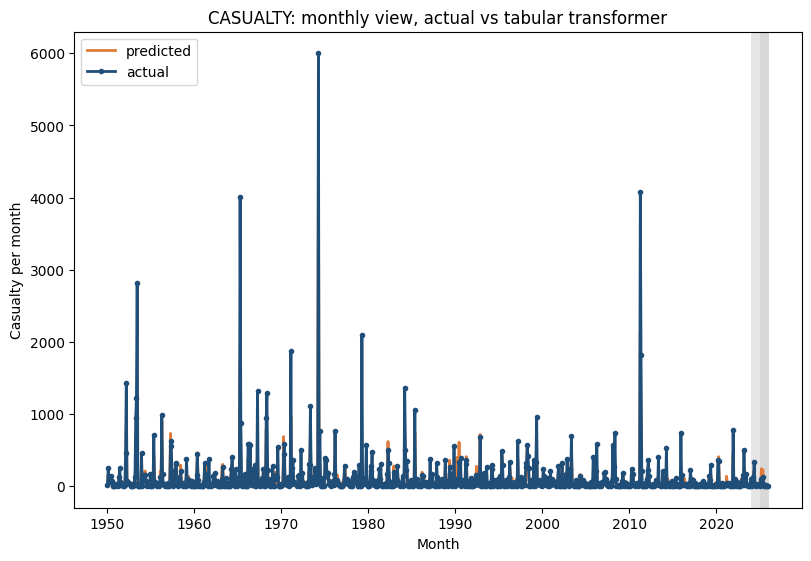

In [ ]:
target_list=PREDICTION_TARGETS
plot_monthly_actual_vs_predicted(forecast_results, target_list)

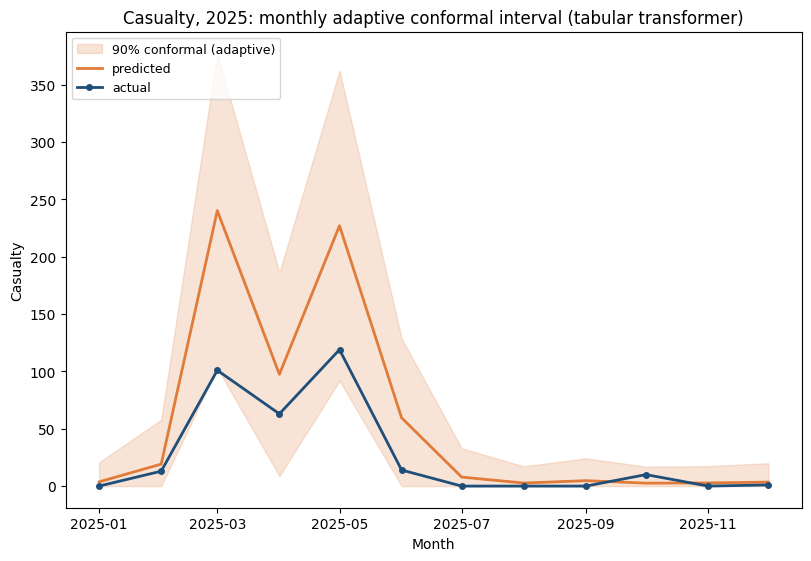

In [ ]:
plot_conformal_monthly(forecast_results, target_list, test_year=2025)

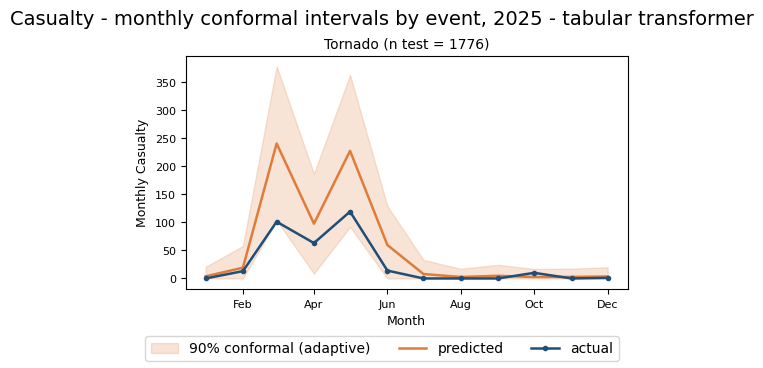

In [ ]:
plot_conformal_monthly_by_event(forecast_results, 'CASUALTY', test_year=2025)

### Historical backtesting

In [ ]:
###################################################
# Historical backtesting
###################################################



BACKTEST_VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def expanding_year_splits(frame, validation_years=BACKTEST_VALIDATION_YEARS):
    """Train on every year strictly before val_year, validate on val_year alone."""
    years = frame.index.year.to_numpy()
    for fold, val_year in enumerate(validation_years, start=1):
        yield (fold, val_year,
               np.flatnonzero(years < val_year),
               np.flatnonzero(years == val_year))



def backtest_target_cv(frame, config, target, epochs,
                       validation_years=BACKTEST_VALIDATION_YEARS):
    """backtesting end-to-end pipeline."""
    index = PREDICTION_TARGETS.index(target)
    records = []

    print("=" * 78)
    print(f"backtesting {target} at {epochs} epochs per fold")
    print("=" * 78)

    for fold, val_year, train_index, val_index in expanding_year_splits(frame, validation_years):
        fold_train = frame.iloc[train_index].copy()
        fold_validation = frame.iloc[val_index].copy()
        encoders = fit_encoders(fold_train)
        tensors = {"train": encode_split(fold_train, encoders),
                   "validation": encode_split(fold_validation, encoders)}
        cardinalities = [len(encoders["vocabularies"][column]) + 1 for column in CATEGORICAL]
        views = {name: target_view(part, index) for name, part in tensors.items()}

        print(f"fold {fold}: train <= {val_year - 1} ({len(fold_train):,} rows)   "
              f"validation = {val_year} ({len(fold_validation):,} rows)")

        baseline_rate = (views["train"]["y"].sum(dim=0)
                         / views["train"]["exposure"].sum()).clamp(min=1e-8)
        fold_params = make_params(config, cardinalities, baseline_rate)
        train_model(fold_params, views["train"], config, epochs=epochs)
        predicted = predict(fold_params, views["validation"])[:, 0]

        records.append(pd.DataFrame(
            {"fold": fold, "validation_year": val_year,
             "actual": views["validation"]["y"][:, 0].cpu().numpy(),
             "predicted": predicted},
            index=fold_validation.index))

        del fold_params, tensors, views, fold_train, fold_validation
        gc.collect()
        torch.cuda.empty_cache()



    return pd.concat(records).sort_index(kind="stable")



In [ ]:
started = time.time()
oof = {target: backtest_target_cv(train_events, BEST_CONFIG[target], target, results[target]["best_epoch"])
       for target in PREDICTION_TARGETS}

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
print(f"\nbacktest wall time: {(time.time() - started) / 60:.1f} min")




backtesting CASUALTY at 3 epochs per fold
fold 1: train <= 2018 (77,411 rows)   validation = 2019 (2,085 rows)
  epoch   1  loss  -1.31578
  epoch   2  loss  -2.00509
  epoch   3  loss  -2.11663
fold 2: train <= 2019 (79,496 rows)   validation = 2020 (1,517 rows)
  epoch   1  loss  -1.40452
  epoch   2  loss  -2.00718
  epoch   3  loss  -2.09113
fold 3: train <= 2020 (81,013 rows)   validation = 2021 (1,728 rows)
  epoch   1  loss  -1.37817
  epoch   2  loss  -1.98902
  epoch   3  loss  -2.13120
fold 4: train <= 2021 (82,741 rows)   validation = 2022 (1,588 rows)
  epoch   1  loss  -1.10696
  epoch   2  loss  -1.84325
  epoch   3  loss  -2.04178
fold 5: train <= 2022 (84,329 rows)   validation = 2023 (1,734 rows)
  epoch   1  loss  -1.24388
  epoch   2  loss  -1.89698
  epoch   3  loss  -2.02513

backtest wall time: 1.2 min


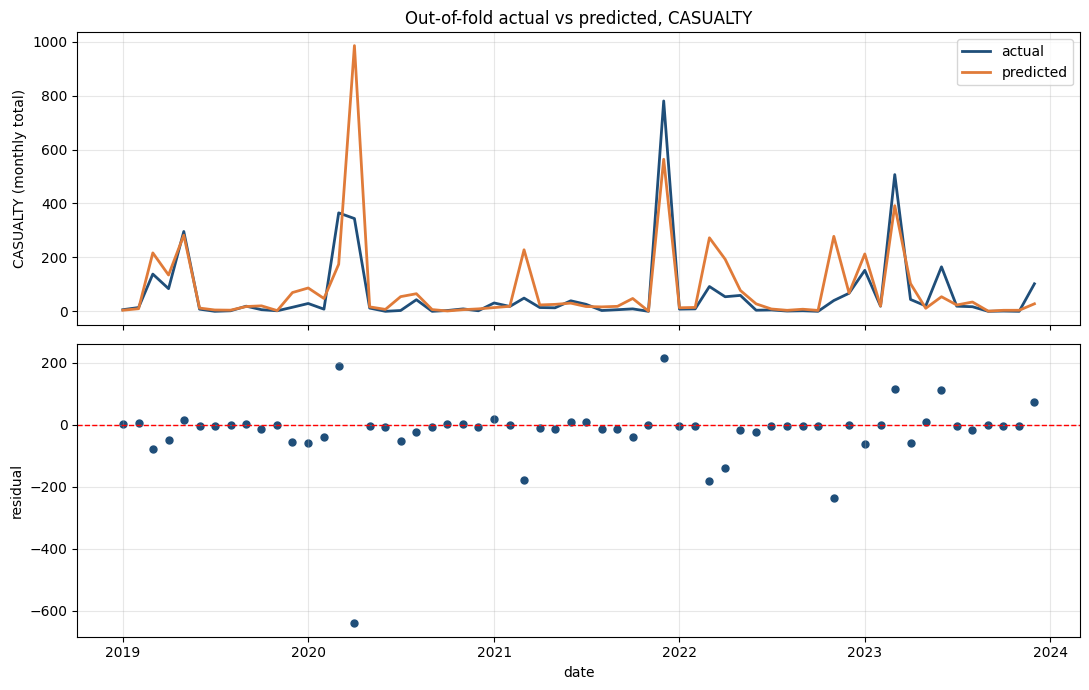

,n,events,D2,RMSE,MPD,ratio
2019,2085.0,82.0,0.6526,2.9872,0.9196,1.3200
2020,1517.0,80.0,0.6500,5.8899,1.5946,1.7847
2021,1728.0,81.0,0.7140,7.0293,1.4901,1.0172
2022,1588.0,76.0,0.3789,3.1366,0.9648,2.8370
2023,1734.0,99.0,0.6290,4.8712,1.7280,0.8473
Mean,1730.4,83.6,0.6049,4.7828,1.3394,1.5612


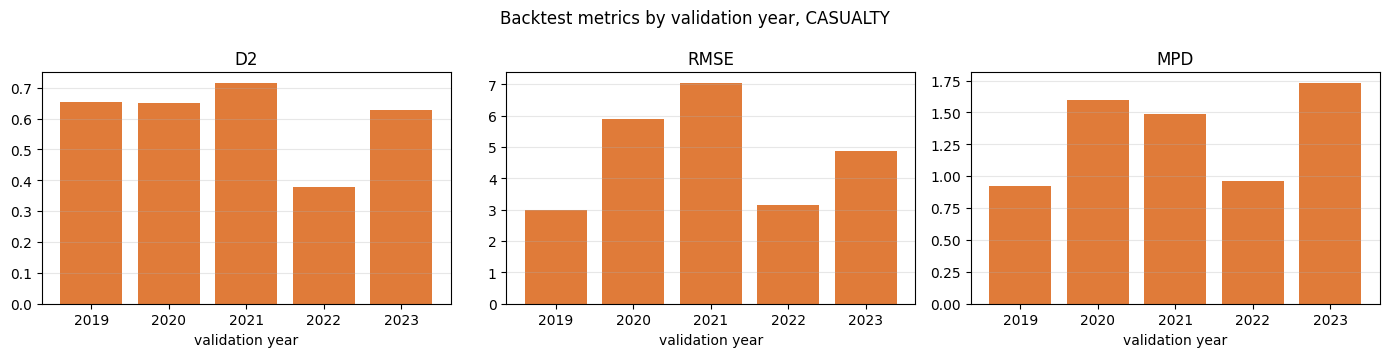

In [ ]:
BACKTEST_FOLD_METRICS = {}


def backtest_report(frame, target):
    """Monthly out-of-fold fit, residuals over time, and metrics by validation year."""
    monthly = frame[["actual", "predicted"]].resample("MS").sum()
    monthly["residual"] = monthly["actual"] - monthly["predicted"]

    figure, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes[0].plot(monthly.index, monthly["actual"], color="#1f4e79", linewidth=2, label="actual")
    axes[0].plot(monthly.index, monthly["predicted"], color="#e07b39", linewidth=2,
                 label="predicted")
    axes[0].set_ylabel(f"{target} (monthly total)")
    axes[0].set_title(f"Out-of-fold actual vs predicted, {target}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].scatter(monthly.index, monthly["residual"], color="#1f4e79", s=25)
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_ylabel("residual")
    axes[1].set_xlabel("date")
    axes[1].grid(alpha=0.3)
    figure.tight_layout()
    plt.show()

    by_year = pd.DataFrame([
        {"year": year, **compute_metrics(block["actual"], block["predicted"]),
         "ratio": block["predicted"].sum() / block["actual"].sum()}
        for year, block in frame.groupby("validation_year")
    ]).set_index("year")

    BACKTEST_FOLD_METRICS[(MODEL_LABEL, target)] = by_year.copy()

    # Mean across validation years
    mean_row = by_year.mean(numeric_only=True).to_frame().T.rename(index={0: "Mean"})
    display(pd.concat([by_year, mean_row]).round(4))

    figure, axes = plt.subplots(1, 3, figsize=(14, 3.6))
    for axis, metric in zip(axes, ["D2", "RMSE", "MPD"]):
        axis.bar(by_year.index.astype(str), by_year[metric], color="#e07b39")
        axis.set_title(metric)
        axis.set_xlabel("validation year")
        axis.grid(alpha=0.3, axis="y")
    figure.suptitle(f"Backtest metrics by validation year, {target}")
    figure.tight_layout()
    plt.show()
    return by_year


backtest_by_year = {target: backtest_report(frame, target) for target, frame in oof.items()}

## From casualties to injuries and deaths

The model predicts one number per tornado: `CASUALTY`, injuries plus deaths. This section checks whether that prediction can be split into its two parts **without building a second model**, and scores the split against the actual injuries and deaths.

In [ ]:
# ==============================================================================
# CASUALTY COMPONENTS, ALIGNED WITH MODEL SPLITS
# ==============================================================================

INJURY_PARTS = ["INJURIES_DIRECT", "INJURIES_INDIRECT"]
DEATH_PARTS = ["DEATHS_DIRECT", "DEATHS_INDIRECT"]
CASUALTY_PARTS = INJURY_PARTS + DEATH_PARTS


def build_casualty_splits(raw, model_splits):
    """Build injury/death components and align them with the model splits."""

    columns = ["BEGIN_DATE_TIME", "EVENT_GROUP", *CASUALTY_PARTS]
    components = raw[columns].copy()

    # Same row preparation used for the modelling dataset
    components["BEGIN_DATE_TIME"] = parse_storm_datetime(
        components["BEGIN_DATE_TIME"]
    )

    components = components.dropna(subset=["BEGIN_DATE_TIME"])
    components = components.loc[
        ~components["EVENT_GROUP"].isin(EXCLUDE_GROUPS)
    ]

    components.index = pd.DatetimeIndex(
        components["BEGIN_DATE_TIME"],
        name="Date"
    )

    components = components.sort_index(kind="stable")

    # Numerical casualty components
    components[CASUALTY_PARTS] = components[CASUALTY_PARTS].astype("float64")

    components["INJURIES"] = components[INJURY_PARTS].sum(axis=1)
    components["DEATHS"] = components[DEATH_PARTS].sum(axis=1)

    components = components.drop(
        columns=["BEGIN_DATE_TIME", "EVENT_GROUP"]
    )

    # Align with the exact modelling splits
    components_by_split = {}

    for split_name, model_frame in model_splits.items():

        part = components.loc[
            model_frame.index.min():model_frame.index.max()
        ]

        # Same rows and same order
        assert part.index.equals(model_frame.index), (
            f"{split_name}: casualty rows are not aligned"
        )

        # Injuries + deaths must reproduce CASUALTY exactly
        rebuilt_casualty = (
            part["INJURIES"] + part["DEATHS"]
        ).to_numpy()

        assert np.allclose(
            rebuilt_casualty,
            model_frame["CASUALTY"].to_numpy()
        ), f"{split_name}: casualty target mismatch"

        components_by_split[split_name] = part

    return components_by_split


components_by_split = build_casualty_splits(
    raw=df,
    model_splits=splits_raw
)

print(
    "Components rebuilt and aligned:",
    {name: len(part) for name, part in components_by_split.items()}
)

Components rebuilt and aligned: {'train': 86063, 'calibration': 2416, 'test': 1776}


In [ ]:
# ==============================================================================
# INJURIES VS DEATHS, SPLIT BY SPLIT
# ==============================================================================

LARGE_EVENT_CASUALTIES = 100


def injury_death_summary(part):

    injuries = part["INJURIES"]
    deaths = part["DEATHS"]
    casualties = injuries + deaths

    without_large_events = casualties <= LARGE_EVENT_CASUALTIES
    total_casualties = casualties.sum()

    return {
        "events": len(part),

        "Pearson":
            injuries.corr(deaths),

        "Spearman":
            injuries.corr(deaths, method="spearman"),

        "Pearson without large events":
            injuries[without_large_events].corr(
                deaths[without_large_events]
            ),

        "P(deaths>0 | injuries>0)":
            deaths[injuries > 0].gt(0).mean(),

        "P(deaths>0 | injuries=0)":
            deaths[injuries == 0].gt(0).mean(),

        "death share":
            deaths.sum() / total_casualties
            if total_casualties > 0 else np.nan,
    }

In [ ]:
###########################################
# DEATHS BY INJURY SIZE
###########################################
INJURY_SIZE_BINS = [0, 5, 20, 100, np.inf]
INJURY_SIZE_LABELS = ["1-5", "6-20", "21-100", ">100"]


def deaths_by_injury_size(part):

    injured = part.loc[
        part["INJURIES"] > 0,
        ["INJURIES", "DEATHS"]
    ]

    injury_size = pd.cut(
        injured["INJURIES"],
        bins=INJURY_SIZE_BINS,
        labels=INJURY_SIZE_LABELS
    )

    grouped = injured.groupby(
        injury_size,
        observed=False
    )["DEATHS"]

    summary = grouped.agg(
        events="size",
        death_probability=lambda deaths: deaths.gt(0).mean(),
        mean_deaths="mean"
    )

    return summary.rename(
        columns={
            "death_probability": "share with at least one death",
            "mean_deaths": "mean deaths",
        }
    )

In [ ]:
# ==============================================================================
# DIRECT VS INDIRECT CASUALTIES, SPLIT BY SPLIT
# ==============================================================================

def direct_indirect_summary(part):

    casualty_parts = part[CASUALTY_PARTS]

    # Calculate once
    events = casualty_parts.gt(0).sum()
    totals = casualty_parts.sum()

    summary = {}

    for column in CASUALTY_PARTS:

        label = column.lower().replace("_", " ")

        summary[f"events with {label}"] = int(events[column])
        summary[f"total {label}"] = float(totals[column])

    total_injuries = totals[INJURY_PARTS].sum()
    total_deaths = totals[DEATH_PARTS].sum()

    summary["indirect share of injuries"] = (
        totals["INJURIES_INDIRECT"] / total_injuries
        if total_injuries > 0 else np.nan
    )

    summary["indirect share of deaths"] = (
        totals["DEATHS_INDIRECT"] / total_deaths
        if total_deaths > 0 else np.nan
    )

    return summary

#### How injuries and deaths move together

* **Pearson correlation**: agreement of the *values*. It is driven by the few large events.
* **Spearman correlation**: agreement of the *rankings*. It gives small and large events the same weight.
* **P(deaths > 0 | injuries > 0)**: among tornadoes that injured someone, the share that also killed someone.
* **Death share**: deaths as a fraction of all casualties.

A high Pearson with a low Spearman means injuries and deaths rise together in big events, while on small events deaths are rare and unrelated to the number injured.

The second table shows the death share by event size.

In [ ]:
for split_name in SPLIT_ORDER:

    part = components_by_split[split_name]

    print(f"\n{'=' * 60}")
    print(split_name.upper())
    print("=" * 60)

    # Table 1: injuries vs deaths
    print("\nInjuries vs deaths")

    display(
        pd.DataFrame(
            injury_death_summary(part),
            index=[split_name]
        ).round(4)
    )

    # Table 2: deaths by injury size
    print("\nDeaths by injury size")

    display(
        deaths_by_injury_size(part).round(3)
    )


TRAIN

Injuries vs deaths


,events,Pearson,Spearman,Pearson without large events,P(deaths>0 | injuries>0),P(deaths>0 | injuries=0),death share
train,86063,0.7418,0.3893,0.4786,0.1804,0.0035,0.0598



Deaths by injury size


,events,share with at least one death,mean deaths
INJURIES,,,
1-5,6045,0.076,0.119
6-20,1715,0.288,0.582
21-100,721,0.641,2.505
>100,146,0.945,15.404



CALIBRATION

Injuries vs deaths


...

,events,share with at least one death,mean deaths
INJURIES,,,
1-5,75,0.133,0.173
6-20,20,0.250,0.250
21-100,8,0.750,2.250
>100,0,NaN,NaN



TEST

Injuries vs deaths


,events,Pearson,Spearman,Pearson without large events,P(deaths>0 | injuries>0),P(deaths>0 | injuries=0),death share
test,1776,0.2984,0.3572,0.2984,0.2105,0.0053,0.1994



Deaths by injury size


,events,share with at least one death,mean deaths
INJURIES,,,
1-5,65,0.169,0.262
6-20,10,0.400,1.100
21-100,1,1.000,4.000
>100,0,NaN,NaN


#### Direct and indirect casualties

NOAA records each casualty as **direct**, caused by the tornado itself, or **indirect**, caused by something the tornado set off. The target adds the two together. The table shows how much each part weighs.

In [ ]:
# ==============================================================================
# CASUALTY SHARES ESTIMATED ON THE TRAINING SET
# ==============================================================================

training_components = components_by_split["train"]

total_casualties = training_components[CASUALTY_PARTS].to_numpy().sum()

PART_SHARES = {
    column_name: training_components[column_name].sum() / total_casualties
    for column_name in CASUALTY_PARTS
}

# Injuries and deaths are the sums of their direct and indirect parts
SHARES = dict(PART_SHARES)

SHARES["INJURIES"] = (
    PART_SHARES["INJURIES_DIRECT"]
    + PART_SHARES["INJURIES_INDIRECT"]
)

SHARES["DEATHS"] = (
    PART_SHARES["DEATHS_DIRECT"]
    + PART_SHARES["DEATHS_INDIRECT"]
)

DEATH_SHARE = SHARES["DEATHS"]


print("Shares estimated on the training years:")

display(
    pd.Series(
        SHARES,
        name="share of casualties"
    ).round(4)
)

Shares estimated on the training years:


,share of casualties
INJURIES_DIRECT,0.9376
INJURIES_INDIRECT,0.0026
DEATHS_DIRECT,0.0594
DEATHS_INDIRECT,0.0004
INJURIES,0.9402
DEATHS,0.0598


#### Splitting the casualty prediction

In [ ]:
# ==============================================================================
# DIRECT VS INDIRECT CASUALTIES, SPLIT BY SPLIT
# ==============================================================================

def direct_indirect_summary(part):

    casualty_parts = part[CASUALTY_PARTS]

    events = casualty_parts.gt(0).sum()
    totals = casualty_parts.sum()

    summary = {}

    for column_name in CASUALTY_PARTS:

        label = column_name.lower().replace("_", " ")

        summary[f"events with {label}"] = events[column_name]
        summary[f"total {label}"] = totals[column_name]

    total_injuries = totals[INJURY_PARTS].sum()
    total_deaths = totals[DEATH_PARTS].sum()

    summary["indirect share of injuries"] = (
        totals["INJURIES_INDIRECT"] / total_injuries
        if total_injuries > 0 else np.nan
    )

    summary["indirect share of deaths"] = (
        totals["DEATHS_INDIRECT"] / total_deaths
        if total_deaths > 0 else np.nan
    )

    return summary


print("Direct vs indirect casualties, by split")

display(
    pd.DataFrame({
        split_name: direct_indirect_summary(part)
        for split_name, part in components_by_split.items()
    }).round(4)
)

Direct vs indirect casualties, by split


,train,calibration,test
events with injuries direct,8584.0000,100.0000,74.000
total injuries direct,98390.0000,649.0000,248.000
events with injuries indirect,65.0000,4.0000,2.000
total injuries indirect,273.0000,9.0000,9.000
events with deaths direct,1812.0000,27.0000,25.000
total deaths direct,6234.0000,51.0000,64.000
events with deaths indirect,37.0000,2.0000,0.000
total deaths indirect,46.0000,2.0000,0.000
indirect share of injuries,0.0028,0.0137,0.035
indirect share of deaths,0.0073,0.0377,0.000


In [ ]:
# ==============================================================================
# CONSTANT-SHARE SPLIT OF THE CASUALTY PREDICTION
# ==============================================================================

train_components = components_by_split["train"]

train_casualties = (
    train_components["INJURIES"].sum()
    + train_components["DEATHS"].sum()
)

# Shares of the four original casualty components
PART_SHARES = {
    component: train_components[component].sum() / train_casualties
    for component in CASUALTY_PARTS
}

# Add the two aggregated targets
SHARES = dict(PART_SHARES)

SHARES["INJURIES"] = (
    PART_SHARES["INJURIES_DIRECT"]
    + PART_SHARES["INJURIES_INDIRECT"]
)

SHARES["DEATHS"] = (
    PART_SHARES["DEATHS_DIRECT"]
    + PART_SHARES["DEATHS_INDIRECT"]
)

DEATH_SHARE = SHARES["DEATHS"]

print(
    f"Death share estimated on the training years: "
    f"{DEATH_SHARE:.4f}"
)


# ------------------------------------------------------------------------------
# Metrics for all casualty components
# ------------------------------------------------------------------------------

casualty_predictions = forecast_results["CASUALTY"]["predictions"]

rows = []

for split_name in SPLIT_ORDER:

    predicted_casualties = casualty_predictions.loc[
        casualty_predictions["split"].eq(split_name),
        "predicted"
    ].to_numpy()

    actual_components = components_by_split[split_name]

    for component, share in SHARES.items():

        actual = actual_components[component].to_numpy()
        forecast = predicted_casualties * share

        rows.append({
            "Target": component,
            "Split": split_name,
            **compute_metrics(actual, forecast),
            "ratio": (
                forecast.sum() / actual.sum()
                if actual.sum() > 0
                else np.nan
            )
        })


component_metrics = (
    _order_splits(pd.DataFrame(rows))
    .set_index(["Target", "Split"])
    .sort_index()
)

Death share estimated on the training years: 0.0598


In [ ]:
# ==============================================================================
# INJURIES AND DEATHS
# ==============================================================================

injury_death_metrics = component_metrics.loc[
    ["DEATHS", "INJURIES"]
]

display(
    injury_death_metrics.round(4)
)

n  events      D2     RMSE     MPD   ratio
Target   Split                                                      
DEATHS   train        86063    1830  0.6192   1.1284  0.2581  0.6409
         calibration   2416      29  0.5193   0.2369  0.0984  0.6658
         test          1776      25  0.5131   0.4206  0.1641  0.6276
INJURIES train        86063    8627  0.6540  13.2509  3.0222  0.6409
         calibration   2416     103  0.5522   2.2984  0.9639  0.8426
         test          1776      76 -0.0165   2.5629  1.0915  2.4554

In [ ]:
# ==============================================================================
# DIRECT AND INDIRECT CASUALTIES
# ==============================================================================

component_order = [
    "DEATHS",
    "DEATHS_DIRECT",
    "DEATHS_INDIRECT",
    "INJURIES",
    "INJURIES_DIRECT",
    "INJURIES_INDIRECT",
]

direct_indirect_metrics = component_metrics.loc[
    component_order
]

display(
    direct_indirect_metrics.round(4)
)

n  events      D2     RMSE     MPD   ratio
Target            Split                                                      
DEATHS            train        86063    1830  0.6192   1.1284  0.2581  0.6409
                  calibration   2416      29  0.5193   0.2369  0.0984  0.6658
                  test          1776      25  0.5131   0.4206  0.1641  0.6276
DEATHS_DIRECT     train        86063    1812  0.6199   1.1197  0.2562  0.6409
                  calibration   2416      27  0.5191   0.2355  0.0962  0.6869
                  test          1776      25  0.5125   0.4208  0.1643  0.6230
DEATHS_INDIRECT   train        86063      37  0.2214   0.0353  0.0066  0.6409
                  calibration   2416       2  0.0921   0.0288  0.0107  0.1292
                  test          1776       0     NaN   0.0011  0.0003     NaN
INJURIES          train        86063    8627  0.6540  13.2509  3.0222  0.6409
                  calibration   2416     103  0.5522   2.2984  0.9639  0.8426
                  test          1776      76 -0.0165   2.5629  1.0915  2.4554
INJURIES_DIRECT   train        86063    8584  0.6545  13.2461  3.0122  0.6409
                  calibration   2416     100  0.5540   2.2860  0.9510  0.8519
                  test          1776      74 -0.0677   2.6254  1.1162  2.5375
INJURIES_INDIRECT train        86063      65  0.0956   0.3502  0.0486  0.6409
                  calibration   2416       4  0.0207   0.1270  0.0495  0.1705
                  test          1776       2  0.5060   0.1886  0.0357  0.1940

## Export

In [ ]:
#############################################################
# EXPORT RESULTS FOR THE COMPARISON NOTEBOOK
#############################################################

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/Storm_Events/tornado_model_results_v2b"
)

EXPORT_KEYS = [
    "metrics",
    "group_metrics",
    "daily_conformal",
    "monthly_conformal",
]


def export_results(
    results,
    name,
    label,
    backtest_metrics=None,
    backtest_oof=None,
    component_metrics=None,
    shares=None,
    results_dir=RESULTS_DIR,
):

    results_dir.mkdir(parents=True, exist_ok=True)

    exported = {}

    for target, result in results.items():

        exported[target] = {
            key: result[key]
            for key in EXPORT_KEYS
        }

        if backtest_metrics is not None and target in backtest_metrics:
            exported[target]["backtest_metrics"] = backtest_metrics[target]

        if backtest_oof is not None and target in backtest_oof:
            exported[target]["backtest_oof"] = backtest_oof[target]

    # Casualty prediction split into injuries/deaths
    # and direct/indirect components
    if component_metrics is not None:

        exported["CASUALTY"]["component_metrics"] = component_metrics

        if shares is not None:
            exported["CASUALTY"]["shares"] = shares
            exported["CASUALTY"]["death_share"] = shares["DEATHS"]

    pd.to_pickle(
        {
            "label": label,
            "results": exported,
        },
        results_dir / f"{name}.pkl"
    )

Mounted at /content/drive


In [ ]:
export_results(
    forecast_results,
    "tabular-transformer",
    "tabular-transformer",
    backtest_metrics=backtest_by_year,
    backtest_oof=oof,
    component_metrics=component_metrics,
    shares=SHARES,
)